In [1]:
import copy
import datetime as dt
from datetime import datetime
import importlib  # needed so that we can reload packages
import logging
import os
import pathlib
import sys
import time
import warnings
from typing import Union, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from utils.logger_utils import setup_clean_logger, mute_external_loggers

# SISEPUEDE imports
from sisepuede.manager.sisepuede_examples import SISEPUEDEExamples
from sisepuede.manager.sisepuede_file_structure import SISEPUEDEFileStructure
import sisepuede.core.support_classes as sc
import sisepuede.transformers as trf
import sisepuede.utilities._plotting as spu
import sisepuede.utilities._toolbox as sf
import sisepuede.core.attribute_table as att
import sisepuede.manager.sisepuede_examples as sxl
import sisepuede.manager.sisepuede_file_structure as sfs
import sisepuede.manager.sisepuede_models as sm
import sisepuede.visualization.plots as svp

# --- Runtime configuration ---
warnings.filterwarnings("ignore")

# Set up a clean logger for your notebook
logger = setup_clean_logger("notebook", logging.INFO)
logger.info("Notebook started successfully.")

# Mute logs from sisepuede to avoid duplication
mute_external_loggers(["sisepuede"])


/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/munch/__init__.py:24: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
2025-12-04 17:42:58,849 - INFO - Notebook started successfully.


In [2]:
%load_ext autoreload
%autoreload 2

### Initial Set up

Make sure to edit the config yaml under ssp_modeling/config_files/config.yaml

You can also create a new config yaml



In [3]:
# Set up dir paths

CURR_DIR_PATH = pathlib.Path(os.getcwd())
SSP_MODELING_DIR_PATH = CURR_DIR_PATH.parent
PROJECT_DIR_PATH = SSP_MODELING_DIR_PATH.parent
DATA_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("input_data")
RUN_OUTPUT_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("ssp_run_output")
SCENARIO_MAPPING_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("scenario_mapping")
CONFIG_DIR_PATH = CURR_DIR_PATH.joinpath("config_files")
TRANSFORMATIONS_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("transformations")
MISC_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("misc")
STRATEGIES_DEFINITIONS_FILE_PATH = TRANSFORMATIONS_DIR_PATH.joinpath("strategy_definitions.csv")
STRATEGY_MAPPING_FILE_PATH = MISC_DIR_PATH.joinpath("strategy_mapping.yaml")

In [4]:
from ssp_transformations_handler.GeneralUtils import GeneralUtils
from ssp_transformations_handler.TransformationUtils import TransformationYamlProcessor, StrategyCSVHandler

# Initialize general utilities
g_utils = GeneralUtils()

In [5]:
# Load config file, double check your parameters are correct

YAML_FILE_PATH = os.path.join(CONFIG_DIR_PATH, "config.yaml")
config_params = g_utils.read_yaml(YAML_FILE_PATH)

country_name = config_params['country_name']
ssp_input_file_name = config_params['ssp_input_file_name']
ssp_transformation_cw = config_params['ssp_transformation_cw']
energy_model_flag = config_params['energy_model_flag']
set_lndu_reallocation_factor_to_zero_flag = config_params['set_lndu_reallocation_factor_to_zero']
sim_end_year = config_params.get('sim_end_year', 2050)  # Default to 2050 if not specified

# Print config parameters
logger.info(f"Country name: {country_name}")
logger.info(f"SSP input file name: {ssp_input_file_name}")
logger.info(f"SSP transformation CW: {ssp_transformation_cw}")
logger.info(f"Energy model flag: {energy_model_flag}")
logger.info(f"Set lndu reallocation factor to zero flag: {set_lndu_reallocation_factor_to_zero_flag}")
logger.info(f"Simulation end year: {sim_end_year}")

2025-12-04 17:42:58,952 - INFO - Country name: bulgaria
2025-12-04 17:42:58,952 - INFO - SSP input file name: sisepuede_raw_inputs_latest_BGR_nov_12.csv
2025-12-04 17:42:58,952 - INFO - SSP transformation CW: ssp_bulgaria_transformation_nov_27.xlsx
2025-12-04 17:42:58,952 - INFO - Energy model flag: True
2025-12-04 17:42:58,952 - INFO - Set lndu reallocation factor to zero flag: True
2025-12-04 17:42:58,953 - INFO - Simulation end year: 2050


In [6]:
def get_file_structure(
    y0: int = 2015,
    y1: int = sim_end_year,
) -> Tuple[sfs.SISEPUEDEFileStructure, att.AttributeTable]:
    """Get the SISEPUEDE File Structure and update the attribute table
        with new years.
    """
    # setup some SISEPUEDE variables and update time period
    file_struct = sfs.SISEPUEDEFileStructure(
        initialize_directories = False,
    )
 
    # get some keys
    key_time_period = file_struct.model_attributes.dim_time_period
    key_year = file_struct.model_attributes.field_dim_year
 
 
    ##  BUILD THE ATTRIBUTE AND UPDATE
 
    # setup the new attribute table
    years = np.arange(y0, y1 + 1, ).astype(int)
    attribute_time_period = att.AttributeTable(
        pd.DataFrame(
            {
                key_time_period: range(len(years)),
                key_year: years,
            }
        ),
        key_time_period,
    )
 
    # finally, update the ModelAttributes inside the file structure
    (
        file_struct
        .model_attributes
        .update_dimensional_attribute_table(
            attribute_time_period,
        )
    )
 
    # return the tuple
    out = (file_struct, attribute_time_period, )
 
    return out


In [7]:
# Set up SSP objects
INPUT_FILE_PATH = DATA_DIR_PATH.joinpath(ssp_input_file_name)

# model attributes and associated support classes
_EXAMPLES = sxl.SISEPUEDEExamples()
_FILE_STRUCTURE, _ATTRIBUTE_TABLE_TIME_PERIOD = get_file_structure()
matt = _FILE_STRUCTURE.model_attributes
regions = sc.Regions(matt, )
time_periods = sc.TimePeriods(matt, )

In [8]:
# # setup models if necessary
# models = sm.SISEPUEDEModels(
#     matt,
#     allow_electricity_run = True,
#     fp_julia = _FILE_STRUCTURE.dir_jl,
#     fp_nemomod_reference_files = _FILE_STRUCTURE.dir_ref_nemo,
#     initialize_julia = True, 
# )

### Making sure our input file has the correct format and correct columns
We use an example df with the complete fields and correct format to make sure our file is in the right shape

In [9]:
INPUT_FILE_PATH

PosixPath('/Users/tony/Documents/sisepuede_modeling/ssp_bulgaria/ssp_modeling/input_data/sisepuede_raw_inputs_latest_BGR_nov_12.csv')

In [10]:
##  BUILD BASE INPUTS
df_inputs_raw = pd.read_csv(INPUT_FILE_PATH)

# pull example data to fill in gaps
df_example_input = _EXAMPLES("input_data_frame")

In [11]:
# Double checking that our df is in the correct shape (Empty sets should be printed to make sure everything is Ok!)
g_utils.compare_dfs(df_example_input, df_inputs_raw)

Columns in df_example but not in df_input: {'region'}
Columns in df_input but not in df_example: {'year', 'iso_alpha_3'}


In [12]:
# Ensure if time_period field exist
if 'time_period' not in df_inputs_raw.columns:
    logger.info("Adding 'time_period' column to df_inputs_raw")
    df_inputs_raw = df_inputs_raw.rename(columns={'period':'time_period'})
else:
    logger.info("'time_period' column already exists in df_inputs_raw")

2025-12-04 17:42:59,690 - INFO - 'time_period' column already exists in df_inputs_raw


In [13]:
# Fixes differences and makes sure that our df is in the correct format.
# Note: Edit this if you need more changes in your df

df_inputs_raw_complete = g_utils.add_missing_cols(df_example_input, df_inputs_raw.copy())
df_inputs_raw_complete.head()

,year,ef_ippu_tonne_nf3_per_tonne_production_chemicals,ef_ippu_tonne_nf3_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_mmm_gdp_other_product_manufacturing,ef_ippu_tonne_sf6_per_tonne_production_chemicals,ef_ippu_tonne_sf6_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_tonne_production_metals,frac_agrc_bevs_and_spices_cl2_dry,frac_agrc_cereals_cl2_dry,frac_agrc_fibers_cl2_dry,...,nemomod_entc_scalar_availability_factor_pp_geothermal,nemomod_entc_scalar_availability_factor_pp_hydropower,nemomod_entc_scalar_availability_factor_pp_nuclear,nemomod_entc_scalar_availability_factor_pp_ocean,nemomod_entc_scalar_availability_factor_pp_oil,nemomod_entc_scalar_availability_factor_pp_solar,nemomod_entc_scalar_availability_factor_pp_waste_incineration,nemomod_entc_scalar_availability_factor_pp_wind,iso_alpha_3,region
0,2015,0.0,0.0,0.000669,0.0,2.653341e-07,0.0,0.085847,0.085847,0.085847,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,BGR,costa_rica
1,2016,0.0,0.0,0.000696,0.0,2.672084e-07,0.0,0.085847,0.085847,0.085847,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,BGR,costa_rica
2,2017,0.0,0.0,0.000307,0.0,1.171112e-07,0.0,0.085847,0.085847,0.085847,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,BGR,costa_rica
3,2018,0.0,0.0,0.000398,0.0,1.287155e-07,0.0,0.085847,0.085847,0.085847,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,BGR,costa_rica
4,2019,0.0,0.0,0.000389,0.0,1.188816e-07,0.0,0.085847,0.085847,0.085847,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,BGR,costa_rica


In [14]:
# Double checking that our df is in the correct shape (Empty sets should be printed to make sure everything is Ok!)
g_utils.compare_dfs(df_example_input, df_inputs_raw_complete)

Columns in df_example but not in df_input: set()
Columns in df_input but not in df_example: {'year', 'iso_alpha_3'}


In [15]:
# check region field
df_inputs_raw_complete['region'].unique()

array(['costa_rica', nan], dtype=object)

In [16]:
# Set region to country name
df_inputs_raw_complete['region'] = country_name
df_inputs_raw_complete['region'].head()

0    bulgaria
1    bulgaria
2    bulgaria
3    bulgaria
4    bulgaria
Name: region, dtype: object

In [17]:
# filter out years beyond sim_end_year
df_inputs_raw_complete = df_inputs_raw_complete[df_inputs_raw_complete["year"] <= sim_end_year]
df_inputs_raw_complete['year'].unique()

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025,
       2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036,
       2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047,
       2048, 2049, 2050])

## Update Drivers

### Socioeconomic

In [18]:
new_socio_df = pd.read_excel(DATA_DIR_PATH.joinpath("GDP_and_population projections.xlsx"), sheet_name="new_gdp_and_pop")
new_socio_df

,year,gdp_growth_rate,population
0,2024,0.034000,6918672
1,2025,0.030000,6860349
2,2026,0.029000,6802438
3,2027,0.031000,6744339
4,2028,0.022804,6685753
5,2029,0.020762,6629192
6,2030,0.020772,6574153
7,2031,0.019891,6520799
8,2032,0.019864,6469093
9,2033,0.019715,6419371


In [19]:
pct_change = (new_socio_df["population"].iloc[-1] - new_socio_df["population"].iloc[0]) \
             / new_socio_df["population"].iloc[0]
pct_change

np.float64(-0.15740289465955315)

In [20]:
df_inputs_raw_complete[["year", "gdp_mmm_usd", "population_gnrl_rural", "population_gnrl_urban"]]

,year,gdp_mmm_usd,population_gnrl_rural,population_gnrl_urban
0,2015,143.440000,1.866995e+06,5.310996e+06
1,2016,147.780000,1.829783e+06,5.298039e+06
2,2017,151.830000,1.792408e+06,5.283539e+06
3,2018,155.930000,1.755697e+06,5.269340e+06
4,2019,162.220000,1.719734e+06,5.256027e+06
5,2020,155.780000,1.685936e+06,5.248079e+06
6,2021,167.720000,1.687028e+06,5.347596e+06
7,2022,174.310000,1.655474e+06,5.345491e+06
8,2023,177.527763,1.623920e+06,5.343387e+06
9,2024,182.386697,1.592366e+06,5.341282e+06


In [21]:
import pandas as pd

# -----------------------------
# 1) Merge base inputs with socio projections
# -----------------------------
# df_inputs_raw_complete : original input df (2015–2050) with:
#   - year
#   - gdp_mmm_usd
#   - population_gnrl_rural
#   - population_gnrl_urban
#
# new_socio_df : socio projections (e.g. 2024–2051) with:
#   - year
#   - gdp_growth_rate
#   - population   (total)
# -----------------------------

updated_input_df = df_inputs_raw_complete.merge(new_socio_df, on="year", how="left")
updated_input_df = updated_input_df.sort_values("year").reset_index(drop=True)

# -----------------------------
# 2) Build total population where missing
#    (for historical years: rural + urban)
# -----------------------------
mask_pop_missing = updated_input_df["population"].isna()
updated_input_df.loc[mask_pop_missing, "population"] = (
    updated_input_df.loc[mask_pop_missing, "population_gnrl_rural"]
    + updated_input_df.loc[mask_pop_missing, "population_gnrl_urban"]
)

# -----------------------------
# 3) Compute rural / urban shares from last known year (2023)
# -----------------------------
last_year = 2023
row_2023 = updated_input_df.loc[updated_input_df["year"] == last_year].iloc[0]

total_2023 = row_2023["population_gnrl_rural"] + row_2023["population_gnrl_urban"]
rural_share = row_2023["population_gnrl_rural"] / total_2023
urban_share = row_2023["population_gnrl_urban"] / total_2023  # or 1 - rural_share

# -----------------------------
# 4) Rebuild GDP from 2024 onward using growth rates
# -----------------------------
updated_input_df["gdp_mmm_usd_rebuilt"] = updated_input_df["gdp_mmm_usd"]

start_year = 2024
years = updated_input_df["year"].values

for i in range(len(updated_input_df)):
    year_i = years[i]
    if year_i >= start_year:
        prev_gdp = updated_input_df.loc[i - 1, "gdp_mmm_usd_rebuilt"]
        growth = updated_input_df.loc[i, "gdp_growth_rate"]
        if pd.notna(growth):
            updated_input_df.loc[i, "gdp_mmm_usd_rebuilt"] = prev_gdp * (1 + growth)

# -----------------------------
# 5) Rebuild rural + urban population from 2024 onward
# -----------------------------
# Initialize rebuilt columns as copies of original (for 2015–2023)
updated_input_df["population_gnrl_rural_rebuilt"] = updated_input_df["population_gnrl_rural"]
updated_input_df["population_gnrl_urban_rebuilt"] = updated_input_df["population_gnrl_urban"]

future_mask = updated_input_df["year"] >= start_year

updated_input_df.loc[future_mask, "population_gnrl_rural_rebuilt"] = (
    updated_input_df.loc[future_mask, "population"] * rural_share
)

updated_input_df.loc[future_mask, "population_gnrl_urban_rebuilt"] = (
    updated_input_df.loc[future_mask, "population"] * urban_share
)


In [22]:
updated_input_df[["year", "gdp_mmm_usd","gdp_mmm_usd_rebuilt", "population_gnrl_rural", "population_gnrl_rural_rebuilt", "population_gnrl_urban", "population_gnrl_urban_rebuilt"]]

,year,gdp_mmm_usd,gdp_mmm_usd_rebuilt,population_gnrl_rural,population_gnrl_rural_rebuilt,population_gnrl_urban,population_gnrl_urban_rebuilt
0,2015,143.440000,143.440000,1.866995e+06,1.866995e+06,5.310996e+06,5.310996e+06
1,2016,147.780000,147.780000,1.829783e+06,1.829783e+06,5.298039e+06,5.298039e+06
2,2017,151.830000,151.830000,1.792408e+06,1.792408e+06,5.283539e+06,5.283539e+06
3,2018,155.930000,155.930000,1.755697e+06,1.755697e+06,5.269340e+06,5.269340e+06
4,2019,162.220000,162.220000,1.719734e+06,1.719734e+06,5.256027e+06,5.256027e+06
5,2020,155.780000,155.780000,1.685936e+06,1.685936e+06,5.248079e+06,5.248079e+06
6,2021,167.720000,167.720000,1.687028e+06,1.687028e+06,5.347596e+06,5.347596e+06
7,2022,174.310000,174.310000,1.655474e+06,1.655474e+06,5.345491e+06,5.345491e+06
8,2023,177.527763,177.527763,1.623920e+06,1.623920e+06,5.343387e+06,5.343387e+06
9,2024,182.386697,183.563707,1.592366e+06,1.612585e+06,5.341282e+06,5.306087e+06


In [23]:
updated_input_df["new_pop_check"] = updated_input_df["population_gnrl_rural_rebuilt"] + updated_input_df["population_gnrl_urban_rebuilt"]

In [24]:
updated_input_df[["year", "population_gnrl_rural", "population_gnrl_rural_rebuilt", "population_gnrl_urban", "population_gnrl_urban_rebuilt", "population", "new_pop_check"]].to_csv(DATA_DIR_PATH.joinpath("socio_data_for_edmundo.csv"), index=False)

<Axes: xlabel='year'>

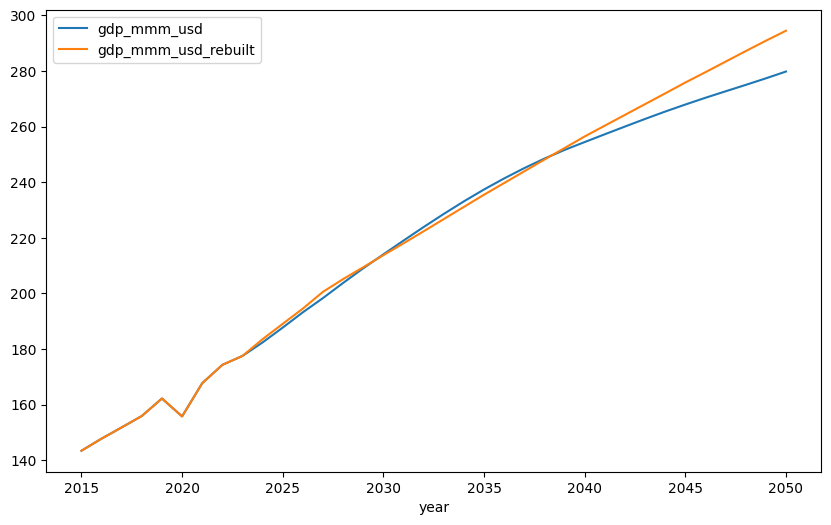

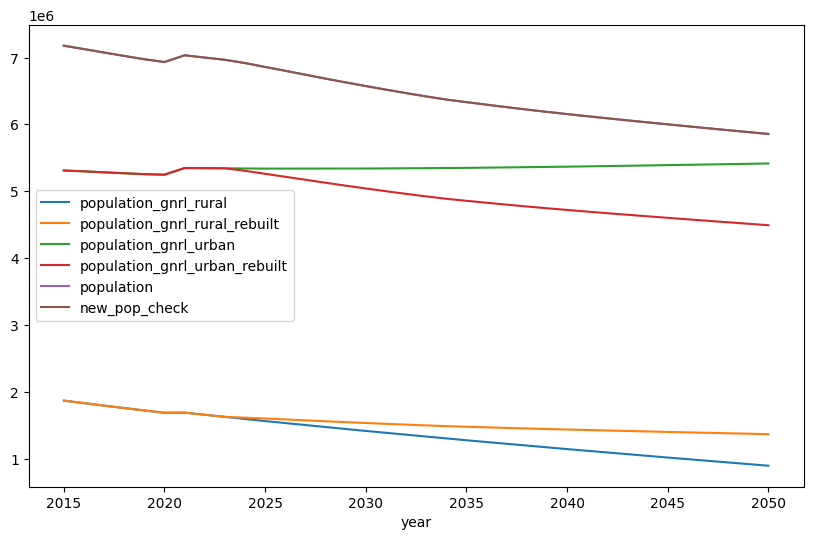

In [25]:
updated_input_df[["year", "gdp_mmm_usd","gdp_mmm_usd_rebuilt"]].plot(x="year", figsize=(10,6))
updated_input_df[["year", "population_gnrl_rural", "population_gnrl_rural_rebuilt", "population_gnrl_urban", "population_gnrl_urban_rebuilt", "population", "new_pop_check"]].plot(x="year", figsize=(10,6))

In [26]:
# -----------------------------------------
# Replace original fields with rebuilt ones
# -----------------------------------------

updated_input_df["gdp_mmm_usd"] = updated_input_df["gdp_mmm_usd_rebuilt"]
updated_input_df["population_gnrl_rural"] = updated_input_df["population_gnrl_rural_rebuilt"]
updated_input_df["population_gnrl_urban"] = updated_input_df["population_gnrl_urban_rebuilt"]

# -----------------------------------------
# Remove helper fields
# -----------------------------------------

cols_to_drop = [
    "gdp_mmm_usd_rebuilt",
    "population_gnrl_rural_rebuilt",
    "population_gnrl_urban_rebuilt",
    "gdp_growth_rate"
]

# Only drop columns that exist (safe)
cols_to_drop = [c for c in cols_to_drop if c in updated_input_df.columns]

updated_input_df = updated_input_df.drop(columns=cols_to_drop)

# -----------------------------------------
# Reset index (optional)
# -----------------------------------------
updated_input_df = updated_input_df.reset_index(drop=True)

In [27]:
pct_change = (updated_input_df["population_gnrl_urban"].iloc[-1] - updated_input_df["population_gnrl_urban"].iloc[0]) \
             / updated_input_df["population_gnrl_urban"].iloc[0]
pct_change

np.float64(-0.154143196566501)

### Crops

**CO2 biomass**

In [28]:
# co2_crop_biomass_fields = [col for col in updated_input_df.columns if "ef_agrc_biomass_" in col and "co2" in col]
# co2_crop_biomass_fields

In [29]:
# updated_input_df[co2_crop_biomass_fields].head()

In [30]:
# # Scale up the biomass emission factors by a factor of 3
# updated_input_df[co2_crop_biomass_fields] = updated_input_df[co2_crop_biomass_fields] * 9.0
# updated_input_df[co2_crop_biomass_fields].head(8)

In [31]:
# initial_crop_area_fields = matt.get_variable("Initial Cropland Area Proportion")
# initial_crop_area_fields.get_from_dataframe(updated_input_df).head(10)

We need to increase crop are for:

- other_woody_perennial
- fruits
- nuts
- bevs_and_spices

In [32]:
# # Update initial crop area fields

# new_vals = {
#     "frac_agrc_initial_area_cropland_bevs_and_spices": 0.020,
#     "frac_agrc_initial_area_cropland_cereals": 0.330,
#     "frac_agrc_initial_area_cropland_fibers": 0.002,
#     "frac_agrc_initial_area_cropland_fruits": 0.150,
#     "frac_agrc_initial_area_cropland_herbs_and_other_perennial_crops": 0.025,
#     "frac_agrc_initial_area_cropland_nuts": 0.090,
#     "frac_agrc_initial_area_cropland_other_annual": 0.140,
#     "frac_agrc_initial_area_cropland_other_woody_perennial": 0.110,
#     "frac_agrc_initial_area_cropland_pulses": 0.022,
#     "frac_agrc_initial_area_cropland_rice": 0.006,
#     "frac_agrc_initial_area_cropland_sugar_cane": 0.000,
#     "frac_agrc_initial_area_cropland_tubers": 0.020,
#     "frac_agrc_initial_area_cropland_vegetables_and_vines": 0.085,
# }




# # Update initial crop area fields with fixed fractions across all rows
# for col, val in new_vals.items():
#     updated_input_df[col] = val

# # Quick check
# updated_input_df[list(new_vals.keys())].head(10)



In [33]:
# # check if they sum to one
# updated_input_df[list(new_vals.keys())].sum(axis=1).unique()

In [34]:
# crop_yf_fields = matt.get_variable("Crop Yield Factor")
# crop_yf_fields.get_from_dataframe(updated_input_df).head(8)

In [35]:
# crop_yf_to_modify = [
#     "yf_agrc_other_woody_perennial_tonne_ha",
#     "yf_agrc_bevs_and_spices_tonne_ha",
#     "yf_agrc_nuts_tonne_ha",
#     "yf_agrc_fruits_tonne_ha"
# ]

# updated_input_df[crop_yf_to_modify].head(8)

In [36]:
# # update the selected crop yield factors by increasing them by 20%
# for col in crop_yf_to_modify:
#     updated_input_df[col] = updated_input_df[col] * 4.5

# updated_input_df[crop_yf_to_modify].head(8)

**CO2 soils**

In [37]:
frac_drain_org_soils = matt.get_variable("Initial Fraction of Area with Drained Organic Soils")
frac_drain_org_soils.get_from_dataframe(updated_input_df).head(10)

,frac_lndu_initial_with_drained_organic_soils_croplands,frac_lndu_initial_with_drained_organic_soils_pastures
0,0.000257,0.011630
1,0.000252,0.012498
2,0.000251,0.012779
3,0.000252,0.012597
4,0.000254,0.012008
5,0.000256,0.011620
6,0.000258,0.011290
7,0.000258,0.011290
8,0.000258,0.011290
9,0.000258,0.011290


In [38]:
updated_input_df[frac_drain_org_soils.fields] *= 0.05
updated_input_df[frac_drain_org_soils.fields].head(10)

,frac_lndu_initial_with_drained_organic_soils_croplands,frac_lndu_initial_with_drained_organic_soils_pastures
0,0.000013,0.000582
1,0.000013,0.000625
2,0.000013,0.000639
3,0.000013,0.000630
4,0.000013,0.000600
5,0.000013,0.000581
6,0.000013,0.000565
7,0.000013,0.000565
8,0.000013,0.000565
9,0.000013,0.000565


In [39]:
soil_organic_stocks_fields = matt.get_variable("Soil Organic C Stocks")
soil_organic_stocks_fields.get_from_dataframe(updated_input_df).head(10)
updated_input_df[soil_organic_stocks_fields.fields] *= 0.5
updated_input_df[soil_organic_stocks_fields.fields].head(10)

,qty_soil_organic_c_stock_dry_climate_tonne_per_ha,qty_soil_organic_c_stock_temperate_crop_grass_tonne_per_ha,qty_soil_organic_c_stock_temperate_forest_nutrient_poor_tonne_per_ha,qty_soil_organic_c_stock_temperate_forest_nutrient_rich_tonne_per_ha,qty_soil_organic_c_stock_tropical_crop_grass_tonne_per_ha,qty_soil_organic_c_stock_tropical_forest_tonne_per_ha,qty_soil_organic_c_stock_wet_climate_tonne_per_ha
0,23.379774,23.379774,23.379774,23.379774,23.379774,23.379774,23.379774
1,23.379774,23.379774,23.379774,23.379774,23.379774,23.379774,23.379774
2,23.379774,23.379774,23.379774,23.379774,23.379774,23.379774,23.379774
3,23.379774,23.379774,23.379774,23.379774,23.379774,23.379774,23.379774
4,23.379774,23.379774,23.379774,23.379774,23.379774,23.379774,23.379774
5,23.379774,23.379774,23.379774,23.379774,23.379774,23.379774,23.379774
6,23.379774,23.379774,23.379774,23.379774,23.379774,23.379774,23.379774
7,23.379774,23.379774,23.379774,23.379774,23.379774,23.379774,23.379774
8,23.379774,23.379774,23.379774,23.379774,23.379774,23.379774,23.379774
9,23.379774,23.379774,23.379774,23.379774,23.379774,23.379774,23.379774


**N20 Biomass**

In [40]:
# check n2o biomass burning emission factor
updated_input_df["ef_agrc_biomass_burning_n2o"].head(8)

0    0.000071
1    0.000071
2    0.000071
3    0.000071
4    0.000071
5    0.000071
6    0.000071
7    0.000071
Name: ef_agrc_biomass_burning_n2o, dtype: float64

In [41]:
# Increase the ef for biomass burning n2o
updated_input_df["ef_agrc_biomass_burning_n2o"] = updated_input_df["ef_agrc_biomass_burning_n2o"] * 1.0
updated_input_df["ef_agrc_biomass_burning_n2o"].head(8)

0    0.000071
1    0.000071
2    0.000071
3    0.000071
4    0.000071
5    0.000071
6    0.000071
7    0.000071
Name: ef_agrc_biomass_burning_n2o, dtype: float64

In [42]:
updated_input_df[["frac_agrc_crop_residues_burned", "frac_agrc_crop_residues_removed"]].head(8)

,frac_agrc_crop_residues_burned,frac_agrc_crop_residues_removed
0,0.025,0.975
1,0.025,0.975
2,0.025,0.975
3,0.025,0.975
4,0.025,0.975
5,0.025,0.975
6,0.025,0.975
7,0.025,0.975


In [43]:
# # # Increase the fraction of crops burned
# updated_input_df["frac_agrc_crop_residues_removed"] = 0.945
# updated_input_df["frac_agrc_crop_residues_burned"] = 1 - updated_input_df["frac_agrc_crop_residues_removed"]
# updated_input_df[["frac_agrc_crop_residues_burned", "frac_agrc_crop_residues_removed"]].head(8)

**CH4 Emissions**

In [44]:
# reduce the emission factor for 'ef_agrc_anaerobicdom_rice_kg_ch4_ha'
updated_input_df["ef_agrc_anaerobicdom_rice_kg_ch4_ha"] = updated_input_df["ef_agrc_anaerobicdom_rice_kg_ch4_ha"] * 0.55
updated_input_df["ef_agrc_anaerobicdom_rice_kg_ch4_ha"].head(8)

0    90.70746
1    90.70746
2    90.70746
3    90.70746
4    90.70746
5    90.70746
6    90.70746
7    90.70746
Name: ef_agrc_anaerobicdom_rice_kg_ch4_ha, dtype: float64

**CO2 Organic Soils**

emission_co2e_co2_soil_urea_use                         
emission_co2e_co2_soil_soc_mineral_soils                
emission_co2e_co2_lndu_drained_organic_soils_pastures    
emission_co2e_co2_soil_lime_use                          

In [45]:
[col for col in updated_input_df.columns if "urea" in col or "mineral" in col or "organic_soils" in col or "lime" in col and ("lndu" in col or "soil" in col)]

['frac_lndu_initial_with_drained_organic_soils_croplands',
 'frac_lndu_initial_with_drained_organic_soils_pastures',
 'ef_soil_c_liming_limestone',
 'ef_soil_c_urea',
 'frac_lndu_soil_mineral_croplands',
 'frac_lndu_soil_mineral_forests_mangroves',
 'frac_lndu_soil_mineral_forests_primary',
 'frac_lndu_soil_mineral_forests_secondary',
 'frac_lndu_soil_mineral_grasslands',
 'frac_lndu_soil_mineral_other',
 'frac_lndu_soil_mineral_settlements',
 'frac_soil_gasf_n_volatilisation_synthetic_fertilizer_non_urea',
 'frac_soil_gasf_n_volatilisation_synthetic_fertilizer_urea',
 'frac_soil_synthetic_fertilizer_urea',
 'qtyinit_soil_liming_limestone_applied_to_soils_kt',
 'frac_lndu_soil_mineral_pastures',
 'frac_lndu_soil_mineral_shrublands',
 'frac_lndu_soil_mineral_wetlands',
 'frac_lndu_soil_mineral_flooded']

In [46]:
frac_lndu_soil_mineral_fields = [col for col in updated_input_df.columns if "frac_lndu_soil_mineral" in col]
updated_input_df[frac_lndu_soil_mineral_fields] = updated_input_df[frac_lndu_soil_mineral_fields] * 0.1
updated_input_df[frac_lndu_soil_mineral_fields].head(8)

,frac_lndu_soil_mineral_croplands,frac_lndu_soil_mineral_forests_mangroves,frac_lndu_soil_mineral_forests_primary,frac_lndu_soil_mineral_forests_secondary,frac_lndu_soil_mineral_grasslands,frac_lndu_soil_mineral_other,frac_lndu_soil_mineral_settlements,frac_lndu_soil_mineral_pastures,frac_lndu_soil_mineral_shrublands,frac_lndu_soil_mineral_wetlands,frac_lndu_soil_mineral_flooded
0,0.100245,0.09721,0.09865,0.097642,0.100171,0.0985,0.097,0.100171,0.100171,0.100171,0.0
1,0.100245,0.09721,0.09865,0.097642,0.100171,0.0985,0.097,0.100171,0.100171,0.100171,0.0
2,0.100245,0.09721,0.09865,0.097642,0.100171,0.0985,0.097,0.100171,0.100171,0.100171,0.0
3,0.100245,0.09721,0.09865,0.097642,0.100171,0.0985,0.097,0.100171,0.100171,0.100171,0.0
4,0.100245,0.09721,0.09865,0.097642,0.100171,0.0985,0.097,0.100171,0.100171,0.100171,0.0
5,0.100245,0.09721,0.09865,0.097642,0.100171,0.0985,0.097,0.100171,0.100171,0.100171,0.0
6,0.100245,0.09721,0.09865,0.097642,0.100171,0.0985,0.097,0.100171,0.100171,0.100171,0.0
7,0.100245,0.09721,0.09865,0.097642,0.100171,0.0985,0.097,0.100171,0.100171,0.100171,0.0


In [47]:
# Reduce the emission factors for urea
updated_input_df["ef_soil_c_urea"] = updated_input_df["ef_soil_c_urea"] * 0.1
updated_input_df["ef_soil_c_urea"].head(8)

0    0.02
1    0.02
2    0.02
3    0.02
4    0.02
5    0.02
6    0.02
7    0.02
Name: ef_soil_c_urea, dtype: float64

In [48]:
updated_input_df['frac_soil_synthetic_fertilizer_urea'] = updated_input_df['frac_soil_synthetic_fertilizer_urea'] * 0.1
updated_input_df['frac_soil_synthetic_fertilizer_urea'].head(8)

0    0.053744
1    0.058974
2    0.055956
3    0.057535
4    0.054571
5    0.054571
6    0.054571
7    0.054571
Name: frac_soil_synthetic_fertilizer_urea, dtype: float64

In [49]:
updated_input_df["ef_soil_c_liming_limestone"] = updated_input_df["ef_soil_c_liming_limestone"] * 0.1
updated_input_df["ef_soil_c_liming_limestone"].head(8)

0    0.01241
1    0.01241
2    0.01241
3    0.01241
4    0.01241
5    0.01241
6    0.01241
7    0.01241
Name: ef_soil_c_liming_limestone, dtype: float64

**N20 Emissions**

In [50]:
updated_input_df[[col for col in updated_input_df.columns if "ef_soil_ef1_n" in col and "fertilizer" in col]].head()

,ef_soil_ef1_n_organic_amerndments_fertilizer_n2o_dry_climate,ef_soil_ef1_n_organic_amerndments_fertilizer_n2o_wet_climate,ef_soil_ef1_n_synthetic_fertilizer_n2o_dry_climate,ef_soil_ef1_n_synthetic_fertilizer_n2o_wet_climate
0,0.005,0.005145,0.005,0.016074
1,0.005,0.005145,0.005,0.016074
2,0.005,0.005145,0.005,0.016074
3,0.005,0.005145,0.005,0.016074
4,0.005,0.005145,0.005,0.016074


In [51]:
initial_synthetic_fertilizer_use_fields = matt.get_variable("Initial Synthetic Fertilizer Use")
fraction_synthetic_fertilizer_use_urea_fields = matt.get_variable("Fraction Synthetic Fertilizer Use Urea")
fertilizer_n_demand_scalar_fields = matt.get_variable("Fertilizer N Demand Scalar")

In [52]:
initial_synthetic_fertilizer_use_fields.get_from_dataframe(updated_input_df).head()

,qtyinit_soil_synthetic_fertilizer_kt
0,3532.7
1,4366.0
2,4377.0
3,4286.6
4,4358.0


In [53]:
updated_input_df[initial_synthetic_fertilizer_use_fields.fields] *= 0.03
updated_input_df[initial_synthetic_fertilizer_use_fields.fields].head()


,qtyinit_soil_synthetic_fertilizer_kt
0,105.981
1,130.980
2,131.310
3,128.598
4,130.740


In [54]:
fraction_synthetic_fertilizer_use_urea_fields.get_from_dataframe(updated_input_df).head()

,frac_soil_synthetic_fertilizer_urea
0,0.053744
1,0.058974
2,0.055956
3,0.057535
4,0.054571


In [55]:
fertilizer_n_demand_scalar_fields.get_from_dataframe(updated_input_df).head()

,demscalar_soil_fertilizer_n_per_area
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0


### Update IPPU

In [56]:
prodinit_fields = matt.get_variable("Initial Industrial Production")
prodinit_fields.get_from_dataframe(updated_input_df).iloc[7].sort_values(ascending=False)

prodinit_ippu_mining_tonne                         4.117546e+07
prodinit_ippu_wood_tonne                           1.833323e+07
prodinit_ippu_cement_tonne                         4.279369e+06
prodinit_ippu_metals_tonne                         3.647140e+06
prodinit_ippu_paper_tonne                          4.947347e+05
prodinit_ippu_plastic_tonne                        3.986763e+05
prodinit_ippu_electronics_tonne                    3.852899e+05
prodinit_ippu_chemicals_tonne                      2.992040e+05
prodinit_ippu_lime_and_carbonite_tonne             2.023870e+05
prodinit_ippu_textiles_tonne                       1.130908e+05
prodinit_ippu_glass_tonne                          9.201359e+04
prodinit_ippu_rubber_and_leather_tonne             1.809911e+04
prodinit_ippu_recycled_metals_tonne                0.000000e+00
prodinit_ippu_recycled_paper_tonne                 0.000000e+00
prodinit_ippu_recycled_plastic_tonne               0.000000e+00
prodinit_ippu_recycled_rubber_and_leathe

In [57]:
prodinit_fields.get_from_dataframe(updated_input_df).tail(10)

,prodinit_ippu_cement_tonne,prodinit_ippu_chemicals_tonne,prodinit_ippu_electronics_tonne,prodinit_ippu_glass_tonne,prodinit_ippu_lime_and_carbonite_tonne,prodinit_ippu_metals_tonne,prodinit_ippu_mining_tonne,prodinit_ippu_paper_tonne,prodinit_ippu_plastic_tonne,prodinit_ippu_recycled_glass_tonne,prodinit_ippu_recycled_metals_tonne,prodinit_ippu_recycled_paper_tonne,prodinit_ippu_recycled_plastic_tonne,prodinit_ippu_recycled_rubber_and_leather_tonne,prodinit_ippu_recycled_textiles_tonne,prodinit_ippu_rubber_and_leather_tonne,prodinit_ippu_textiles_tonne,prodinit_ippu_wood_tonne
26,6736296.375,597752.218921,1.051644e+06,218383.673277,1.480175e+12,8.700975e+06,9.570217e+07,9.332973e+05,1.077781e+06,0.0,0.0,0.0,0.0,0.0,0.0,57780.797633,127751.551843,18333230.0
27,6899089.623,619925.948783,1.108716e+06,228547.454428,3.400815e+12,9.108407e+06,1.000460e+08,9.650010e+05,1.135698e+06,0.0,0.0,0.0,0.0,0.0,0.0,61420.944606,128573.787760,18333230.0
28,7065817.028,642922.217284,1.168886e+06,239184.267494,7.813633e+12,9.534917e+06,1.045871e+08,9.977817e+05,1.196726e+06,0.0,0.0,0.0,0.0,0.0,0.0,65290.418112,129401.315762,18333230.0
29,7236573.663,666771.536646,1.232321e+06,250316.127826,1.795242e+13,9.981399e+06,1.093342e+08,1.031676e+06,1.261035e+06,0.0,0.0,0.0,0.0,0.0,0.0,69403.665551,130234.169908,18333230.0
30,7411456.902,691505.550951,1.299198e+06,261966.075387,4.124706e+13,1.044879e+07,1.142968e+08,1.066722e+06,1.328798e+06,0.0,0.0,0.0,0.0,0.0,0.0,73776.044497,131072.384479,18333230.0
31,7590566.471,717157.078121,1.369705e+06,274158.222443,9.476829e+13,1.093806e+07,1.194847e+08,1.102958e+06,1.400204e+06,0.0,0.0,0.0,0.0,0.0,0.0,78423.880042,131915.993975,18333230.0
32,7774004.506,743760.153469,1.444038e+06,286917.803468,2.177374e+14,1.145025e+07,1.249080e+08,1.140425e+06,1.475446e+06,0.0,0.0,0.0,0.0,0.0,0.0,83364.525745,132765.033120,18333230.0
33,7961875.611,771350.074850,1.522405e+06,300271.227371,5.002684e+14,1.198642e+07,1.305775e+08,1.179165e+06,1.554732e+06,0.0,0.0,0.0,0.0,0.0,0.0,88616.428427,133619.536860,18333230.0
34,8154286.918,799963.449502,1.605025e+06,314246.132157,1.149405e+15,1.254769e+07,1.365043e+08,1.219220e+06,1.638278e+06,0.0,0.0,0.0,0.0,0.0,0.0,94199.197044,134479.540367,18333230.0
35,8351348.148,829638.242614,1.692129e+06,328871.442131,2.640846e+15,1.313525e+07,1.427001e+08,1.260637e+06,1.726314e+06,0.0,0.0,0.0,0.0,0.0,0.0,100133.675903,135345.079037,18333230.0


In [58]:
scaling_factors_bg_ippu = {
    "prodinit_ippu_cement_tonne":                         0.6,  # slightly down
    "prodinit_ippu_chemicals_tonne":                      0.025,  # up a bit (underrepresented)
    "prodinit_ippu_electronics_tonne":                    1.5,
    "prodinit_ippu_glass_tonne":                          1.50,
    "prodinit_ippu_lime_and_carbonite_tonne":             50,
    "prodinit_ippu_metals_tonne":                         0.35,  # small downscale
    "prodinit_ippu_mining_tonne":                         0.25,  # big downscale (too huge vs GDP share)
    "prodinit_ippu_paper_tonne":                          0.80,
    "prodinit_ippu_plastic_tonne":                        0.30,

    # Recycling: scaling 1.0 (no effect) – you’ll still need to seed non-zero baselines manually
    "prodinit_ippu_recycled_glass_tonne":                 1.00,
    "prodinit_ippu_recycled_metals_tonne":                1.00,
    "prodinit_ippu_recycled_paper_tonne":                 1.00,
    "prodinit_ippu_recycled_plastic_tonne":               1.00,
    "prodinit_ippu_recycled_rubber_and_leather_tonne":    1.00,
    "prodinit_ippu_recycled_textiles_tonne":              1.00,

    "prodinit_ippu_rubber_and_leather_tonne":             1.5, # strong increase
    "prodinit_ippu_textiles_tonne":                       0.80,
    "prodinit_ippu_wood_tonne":                           0.30,  # big downscale (too dominant)
}


for col, factor in scaling_factors_bg_ippu.items():
    if col in updated_input_df.columns:
        updated_input_df[col] = updated_input_df[col] * factor


In [59]:
prodinit_fields.get_from_dataframe(updated_input_df).iloc[7]

prodinit_ippu_cement_tonne                         2.567622e+06
prodinit_ippu_chemicals_tonne                      7.480101e+03
prodinit_ippu_electronics_tonne                    5.779348e+05
prodinit_ippu_glass_tonne                          1.380204e+05
prodinit_ippu_lime_and_carbonite_tonne             1.011935e+07
prodinit_ippu_metals_tonne                         1.276499e+06
prodinit_ippu_mining_tonne                         1.029387e+07
prodinit_ippu_paper_tonne                          3.957878e+05
prodinit_ippu_plastic_tonne                        1.196029e+05
prodinit_ippu_recycled_glass_tonne                 0.000000e+00
prodinit_ippu_recycled_metals_tonne                0.000000e+00
prodinit_ippu_recycled_paper_tonne                 0.000000e+00
prodinit_ippu_recycled_plastic_tonne               0.000000e+00
prodinit_ippu_recycled_rubber_and_leather_tonne    0.000000e+00
prodinit_ippu_recycled_textiles_tonne              0.000000e+00
prodinit_ippu_rubber_and_leather_tonne  

**Check elasticities**

In [60]:
ippu_prod_elasticities_fields = matt.get_variable("Elasticity of Industrial Production to GDP")
ippu_prod_elasticities_fields.get_from_dataframe(updated_input_df).head(10)

,elasticity_ippu_cement_production_to_gdp,elasticity_ippu_chemicals_production_to_gdp,elasticity_ippu_electronics_production_to_gdp,elasticity_ippu_glass_production_to_gdp,elasticity_ippu_lime_and_carbonite_production_to_gdp,elasticity_ippu_metals_production_to_gdp,elasticity_ippu_mining_production_to_gdp,elasticity_ippu_paper_production_to_gdp,elasticity_ippu_plastic_production_to_gdp,elasticity_ippu_rubber_and_leather_production_to_gdp,elasticity_ippu_textiles_production_to_gdp,elasticity_ippu_wood_production_to_gdp
0,28.277476,-19.363667,-10.371178,19.066233,42.059537,16.967509,15.711407,7.792454,-6.365421,7.262124,13.879090,0.5
1,14.726944,-28.143452,-55.984056,-50.004838,11.927801,-49.029891,-40.801225,-19.061907,-39.546275,-26.832748,-49.546792,0.5
2,1.975943,28.766378,38.457250,30.212123,29.369519,25.627065,23.604182,51.369948,39.920770,52.296187,34.141406,0.5
3,-4.982407,-1.196341,1.025687,10.814672,4.478882,1.033295,-2.633950,3.085947,10.202271,6.210359,1.663388,0.5
4,13.713241,-16.917346,14.070968,-17.278433,-49.917440,20.907289,0.141504,-20.762947,-2.651003,-16.208534,16.136001,0.5
5,0.540583,-0.500000,-0.500000,-0.484622,2.000000,0.696955,-0.500000,-0.221378,0.001046,1.082201,1.016299,0.5
6,0.555897,-0.450000,-0.450000,-0.435135,1.966667,0.707056,-0.450000,-0.180666,0.034345,1.079461,1.015755,0.5
7,0.571210,-0.400000,-0.400000,-0.385647,1.933333,0.717158,-0.400000,-0.139953,0.067643,1.076721,1.015212,0.5
8,0.586524,-0.350000,-0.350000,-0.336160,1.900000,0.727259,-0.350000,-0.099241,0.100942,1.073981,1.014669,0.5
9,0.601838,-0.300000,-0.300000,-0.286672,1.866667,0.737361,-0.300000,-0.058528,0.134240,1.071241,1.014125,0.5


In [61]:
# Make all elasticities 0.5
for col in ippu_prod_elasticities_fields.fields:
    if col in updated_input_df.columns:
        updated_input_df[col] = 0.5

In [62]:
scaling_factors_elasticity_ippu = {
    "elasticity_ippu_cement_production_to_gdp": 1.0,
    "elasticity_ippu_chemicals_production_to_gdp": 0.15,
    "elasticity_ippu_lime_and_carbonite_production_to_gdp": 1.40,
    "elasticity_ippu_metals_production_to_gdp": 1.0
}


for col, factor in scaling_factors_elasticity_ippu.items():
    if col in updated_input_df.columns:
        updated_input_df[col] = updated_input_df[col] * factor


In [63]:
ippu_prod_elasticities_fields.get_from_dataframe(updated_input_df).head(10)

,elasticity_ippu_cement_production_to_gdp,elasticity_ippu_chemicals_production_to_gdp,elasticity_ippu_electronics_production_to_gdp,elasticity_ippu_glass_production_to_gdp,elasticity_ippu_lime_and_carbonite_production_to_gdp,elasticity_ippu_metals_production_to_gdp,elasticity_ippu_mining_production_to_gdp,elasticity_ippu_paper_production_to_gdp,elasticity_ippu_plastic_production_to_gdp,elasticity_ippu_rubber_and_leather_production_to_gdp,elasticity_ippu_textiles_production_to_gdp,elasticity_ippu_wood_production_to_gdp
0,0.5,0.075,0.5,0.5,0.7,0.5,0.5,0.5,0.5,0.5,0.5,0.5
1,0.5,0.075,0.5,0.5,0.7,0.5,0.5,0.5,0.5,0.5,0.5,0.5
2,0.5,0.075,0.5,0.5,0.7,0.5,0.5,0.5,0.5,0.5,0.5,0.5
3,0.5,0.075,0.5,0.5,0.7,0.5,0.5,0.5,0.5,0.5,0.5,0.5
4,0.5,0.075,0.5,0.5,0.7,0.5,0.5,0.5,0.5,0.5,0.5,0.5
5,0.5,0.075,0.5,0.5,0.7,0.5,0.5,0.5,0.5,0.5,0.5,0.5
6,0.5,0.075,0.5,0.5,0.7,0.5,0.5,0.5,0.5,0.5,0.5,0.5
7,0.5,0.075,0.5,0.5,0.7,0.5,0.5,0.5,0.5,0.5,0.5,0.5
8,0.5,0.075,0.5,0.5,0.7,0.5,0.5,0.5,0.5,0.5,0.5,0.5
9,0.5,0.075,0.5,0.5,0.7,0.5,0.5,0.5,0.5,0.5,0.5,0.5


**N2O Update**

In [64]:
updated_input_df["ef_ippu_tonne_n2o_per_mmm_gdp_other_product_manufacturing"].head()

0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
Name: ef_ippu_tonne_n2o_per_mmm_gdp_other_product_manufacturing, dtype: float64

In [65]:
updated_input_df["ef_ippu_tonne_n2o_per_mmm_gdp_other_product_manufacturing"] = updated_input_df["ef_ippu_tonne_n2o_per_mmm_gdp_other_product_manufacturing"] * 0.1
updated_input_df["ef_ippu_tonne_n2o_per_mmm_gdp_other_product_manufacturing"].head()

0    0.1
1    0.1
2    0.1
3    0.1
4    0.1
Name: ef_ippu_tonne_n2o_per_mmm_gdp_other_product_manufacturing, dtype: float64

**SF6 Update**

In [66]:
updated_input_df[[col for col in updated_input_df.columns if "other_product_manufacturing" in col and "ippu" in col]].head(10)

,ef_ippu_tonne_sf6_per_mmm_gdp_other_product_manufacturing,demscalar_ippu_other_product_manufacturing,ef_ippu_tonne_n2o_per_mmm_gdp_other_product_manufacturing
0,0.000669,1.0,0.1
1,0.000696,1.0,0.1
2,0.000307,1.0,0.1
3,0.000398,1.0,0.1
4,0.000389,1.0,0.1
5,0.000380,1.0,0.1
6,0.000485,1.0,0.1
7,0.000485,1.0,0.1
8,0.000485,1.0,0.1
9,0.000485,1.0,0.1


In [67]:
updated_input_df["ef_ippu_tonne_sf6_per_mmm_gdp_other_product_manufacturing"] = updated_input_df["ef_ippu_tonne_sf6_per_mmm_gdp_other_product_manufacturing"] * 10.0
updated_input_df["ef_ippu_tonne_sf6_per_mmm_gdp_other_product_manufacturing"].head()

0    0.006694
1    0.006958
2    0.003071
3    0.003982
4    0.003887
Name: ef_ippu_tonne_sf6_per_mmm_gdp_other_product_manufacturing, dtype: float64

**HFC update**

In [68]:
updated_input_df[[col for col in updated_input_df.columns if "product_use_ods" in col]].iloc[7]

ef_ippu_tonne_c2hf5_per_mmm_gdp_product_use_ods_other                      1.508735
ef_ippu_tonne_c2hf5_per_mmm_gdp_product_use_ods_refrigeration              1.508735
ef_ippu_tonne_chf2cf3_per_mmm_gdp_product_use_ods_other                    1.918237
ef_ippu_tonne_chf2cf3_per_mmm_gdp_product_use_ods_refrigeration            1.918237
ef_ippu_tonne_c2h3f3_per_mmm_gdp_product_use_ods_refrigeration             0.117016
ef_ippu_tonne_ch3chf2_per_mmm_gdp_product_use_ods_other                    0.000004
ef_ippu_tonne_ch3chf2_per_mmm_gdp_product_use_ods_refrigeration            0.000004
ef_ippu_tonne_c3hf7_per_mmm_gdp_product_use_ods_other                      0.000000
ef_ippu_tonne_c3hf7_per_mmm_gdp_product_use_ods_refrigeration              0.000000
ef_ippu_tonne_chf3_per_mmm_gdp_product_use_ods_other                       0.000117
ef_ippu_tonne_chf3_per_mmm_gdp_product_use_ods_refrigeration               0.000117
ef_ippu_tonne_c3h2f6_per_mmm_gdp_product_use_ods_other                     0

In [69]:
product_use_ef_fields = [col for col in updated_input_df.columns if "product_use_ods" in col and "ef_ippu" in col]
product_use_elasticity_fields = [col for col in updated_input_df.columns if "product_use_ods" in col and "elasticity_ippu" in col]
product_use_elasticity_fields

['elasticity_ippu_product_use_ods_other_product_use_rate_to_gdppc',
 'elasticity_ippu_product_use_ods_refrigeration_product_use_rate_to_gdppc']

In [70]:
updated_input_df[product_use_ef_fields] = updated_input_df[product_use_ef_fields] * 0.118
updated_input_df[product_use_elasticity_fields] = updated_input_df[product_use_elasticity_fields] * 1.0

### Update Livestock

In [71]:
manure_methane_correction_factor_fields = matt.get_variable("Manure Management Methane Correction Factor")
manure_methane_correction_factor_fields.get_from_dataframe(updated_input_df).head(10)

,mcf_lsmm_anaerobic_digester,mcf_lsmm_anaerobic_lagoon,mcf_lsmm_composting,mcf_lsmm_daily_spread,mcf_lsmm_deep_bedding,mcf_lsmm_dry_lot,mcf_lsmm_incineration,mcf_lsmm_liquid_slurry,mcf_lsmm_paddock_pasture_range,mcf_lsmm_poultry_manure,mcf_lsmm_storage_solid
0,0.065581,0.725371,0.012296,0.005144,0.234958,0.013575,0.102081,0.367223,0.004731,0.015029,0.028768
1,0.065581,0.725371,0.012296,0.005144,0.234958,0.013575,0.102081,0.367223,0.004731,0.015029,0.028768
2,0.065581,0.725371,0.012296,0.005144,0.234958,0.013575,0.102081,0.367223,0.004731,0.015029,0.028768
3,0.065581,0.725371,0.012296,0.005144,0.234958,0.013575,0.102081,0.367223,0.004731,0.015029,0.028768
4,0.065581,0.725371,0.012296,0.005144,0.234958,0.013575,0.102081,0.367223,0.004731,0.015029,0.028768
5,0.065581,0.725371,0.012296,0.005144,0.234958,0.013575,0.102081,0.367223,0.004731,0.015029,0.028768
6,0.065581,0.725371,0.012296,0.005144,0.234958,0.013575,0.102081,0.367223,0.004731,0.015029,0.028768
7,0.065581,0.725371,0.012296,0.005144,0.234958,0.013575,0.102081,0.367223,0.004731,0.015029,0.028768
8,0.065581,0.725371,0.012296,0.005144,0.234958,0.013575,0.102081,0.367223,0.004731,0.015029,0.028768
9,0.065581,0.725371,0.012296,0.005144,0.234958,0.013575,0.102081,0.367223,0.004731,0.015029,0.028768


In [72]:
updated_input_df[manure_methane_correction_factor_fields.fields] = updated_input_df[manure_methane_correction_factor_fields.fields] * 0.75
updated_input_df[manure_methane_correction_factor_fields.fields].head(10)

,mcf_lsmm_anaerobic_digester,mcf_lsmm_anaerobic_lagoon,mcf_lsmm_composting,mcf_lsmm_daily_spread,mcf_lsmm_deep_bedding,mcf_lsmm_dry_lot,mcf_lsmm_incineration,mcf_lsmm_liquid_slurry,mcf_lsmm_paddock_pasture_range,mcf_lsmm_poultry_manure,mcf_lsmm_storage_solid
0,0.049186,0.544028,0.009222,0.003858,0.176218,0.010182,0.076561,0.275417,0.003548,0.011272,0.021576
1,0.049186,0.544028,0.009222,0.003858,0.176218,0.010182,0.076561,0.275417,0.003548,0.011272,0.021576
2,0.049186,0.544028,0.009222,0.003858,0.176218,0.010182,0.076561,0.275417,0.003548,0.011272,0.021576
3,0.049186,0.544028,0.009222,0.003858,0.176218,0.010182,0.076561,0.275417,0.003548,0.011272,0.021576
4,0.049186,0.544028,0.009222,0.003858,0.176218,0.010182,0.076561,0.275417,0.003548,0.011272,0.021576
5,0.049186,0.544028,0.009222,0.003858,0.176218,0.010182,0.076561,0.275417,0.003548,0.011272,0.021576
6,0.049186,0.544028,0.009222,0.003858,0.176218,0.010182,0.076561,0.275417,0.003548,0.011272,0.021576
7,0.049186,0.544028,0.009222,0.003858,0.176218,0.010182,0.076561,0.275417,0.003548,0.011272,0.021576
8,0.049186,0.544028,0.009222,0.003858,0.176218,0.010182,0.076561,0.275417,0.003548,0.011272,0.021576
9,0.049186,0.544028,0.009222,0.003858,0.176218,0.010182,0.076561,0.275417,0.003548,0.011272,0.021576


In [73]:
ef_lsmm_direct_management_fields = [col for col in updated_input_df.columns if "ef_lsmm_direct_management_" in col]
updated_input_df[ef_lsmm_direct_management_fields] = updated_input_df[ef_lsmm_direct_management_fields] * 1.70

In [74]:
ef_lvst_entferm_fields = [col for col in updated_input_df.columns if "ef_lvst_entferm_" in col]
updated_input_df[ef_lvst_entferm_fields] = updated_input_df[ef_lvst_entferm_fields] * 1.035

### Update Waste

**CH4 Solid Waste**

In [75]:
matt.get_variable("Average Methane Correction Factor at Landfills").get_from_dataframe(updated_input_df).head(10)

,mcf_waso_average_landfilled
0,0.66
1,0.66
2,0.66
3,0.66
4,0.66
5,0.66
6,0.66
7,0.66
8,0.66
9,0.66


In [76]:
matt.get_variable("Average Methane Correction Factor for Open Dumping").get_from_dataframe(updated_input_df).head(10)

,mcf_waso_average_open_dump
0,0.5
1,0.5
2,0.5
3,0.5
4,0.5
5,0.5
6,0.5
7,0.5
8,0.5
9,0.5


In [77]:
# scale down the methane correction factors
updated_input_df["mcf_waso_average_landfilled"] = updated_input_df["mcf_waso_average_landfilled"] * 0.7
updated_input_df["mcf_waso_average_open_dump"] = updated_input_df["mcf_waso_average_open_dump"] * 0.7

In [78]:
updated_input_df["mcf_waso_average_landfilled"].head(10)

0    0.462
1    0.462
2    0.462
3    0.462
4    0.462
5    0.462
6    0.462
7    0.462
8    0.462
9    0.462
Name: mcf_waso_average_landfilled, dtype: float64

In [79]:
updated_input_df["mcf_waso_average_open_dump"].head(10)

0    0.35
1    0.35
2    0.35
3    0.35
4    0.35
5    0.35
6    0.35
7    0.35
8    0.35
9    0.35
Name: mcf_waso_average_open_dump, dtype: float64

**WASO CO2**

In [80]:
updated_input_df[[col for col in updated_input_df.columns if "frac_waso_non_recycled" in col]].head(10)

,frac_waso_non_recycled_incinerated,frac_waso_non_recycled_landfilled,frac_waso_non_recycled_open_dump
0,0.022049,0.530931,0.44702
1,0.022049,0.530931,0.44702
2,0.022049,0.530931,0.44702
3,0.022049,0.530931,0.44702
4,0.022049,0.530931,0.44702
5,0.022049,0.530931,0.44702
6,0.022049,0.530931,0.44702
7,0.022049,0.530931,0.44702
8,0.022049,0.530931,0.44702
9,0.022049,0.530931,0.44702


In [81]:
updated_input_df["frac_waso_non_recycled_incinerated"] = 0.0015
updated_input_df["frac_waso_non_recycled_landfilled"] = 0.5285
updated_input_df["frac_waso_non_recycled_open_dump"] = 0.47
updated_input_df[[col for col in updated_input_df.columns if "frac_waso_non_recycled" in col]].sum(axis=1).unique()


array([1.])

**N2O and CH4 Wastewater Treatement**

In [82]:
ef_trww_fields = [col for col in updated_input_df.columns if "ef_trww" in col]
frac_n2o_trww_fields = matt.get_variable("Fraction of Nitrogen Removed in Treatment")
frac_tow_trww_fields = matt.get_variable("Fraction of Total Organic Waste Removed in Treatment")
ch4_cf_trww_fields = matt.get_variable("Wastewater Treatment Methane Correction Factor")

In [83]:
updated_input_df[ef_trww_fields].loc[7]

ef_trww_treated_advanced_aerobic_g_n2o_per_g_n       0.0160
ef_trww_treated_advanced_anaerobic_g_n2o_per_g_n     0.0005
ef_trww_treated_latrine_improved_g_n2o_per_g_n       0.0005
ef_trww_treated_latrine_unimproved_g_n2o_per_g_n     0.0005
ef_trww_treated_primary_g_n2o_per_g_n                0.0160
ef_trww_treated_secondary_aerobic_g_n2o_per_g_n      0.0160
ef_trww_treated_secondary_anaerobic_g_n2o_per_g_n    0.0005
ef_trww_treated_septic_g_n2o_per_g_n                 0.0025
ef_trww_untreated_no_sewerage_g_n2o_per_g_n          0.0120
ef_trww_untreated_with_sewerage_g_n2o_per_g_n        0.0120
Name: 7, dtype: float64

In [84]:
frac_n2o_trww_fields.get_from_dataframe(updated_input_df).loc[7]

frac_trww_n_removed_treated_advanced_aerobic       0.80
frac_trww_n_removed_treated_advanced_anaerobic     0.80
frac_trww_n_removed_treated_latrine_improved       0.12
frac_trww_n_removed_treated_latrine_unimproved     0.12
frac_trww_n_removed_treated_primary                0.10
frac_trww_n_removed_treated_secondary_aerobic      0.40
frac_trww_n_removed_treated_secondary_anaerobic    0.40
frac_trww_n_removed_treated_septic                 0.15
frac_trww_n_removed_untreated_no_sewerage          0.00
frac_trww_n_removed_untreated_with_sewerage        0.00
Name: 7, dtype: float64

In [85]:
frac_tow_trww_fields.get_from_dataframe(updated_input_df).loc[7]

frac_trww_tow_removed_treated_advanced_aerobic       0.900
frac_trww_tow_removed_treated_advanced_anaerobic     0.900
frac_trww_tow_removed_treated_latrine_improved       0.600
frac_trww_tow_removed_treated_latrine_unimproved     0.100
frac_trww_tow_removed_treated_primary                0.400
frac_trww_tow_removed_treated_secondary_aerobic      0.850
frac_trww_tow_removed_treated_secondary_anaerobic    0.850
frac_trww_tow_removed_treated_septic                 0.625
frac_trww_tow_removed_untreated_no_sewerage          0.000
frac_trww_tow_removed_untreated_with_sewerage        0.000
Name: 7, dtype: float64

In [86]:
ch4_cf_trww_fields.get_from_dataframe(updated_input_df).loc[7]

mcf_trww_treated_advanced_aerobic       0.03
mcf_trww_treated_advanced_anaerobic     0.60
mcf_trww_treated_latrine_improved       0.60
mcf_trww_treated_latrine_unimproved     0.10
mcf_trww_treated_primary                0.03
mcf_trww_treated_secondary_aerobic      0.03
mcf_trww_treated_secondary_anaerobic    0.60
mcf_trww_treated_septic                 0.50
mcf_trww_untreated_no_sewerage          0.30
mcf_trww_untreated_with_sewerage        0.25
Name: 7, dtype: float64

In [87]:
updated_input_df["frac_trww_n_removed_untreated_no_sewerage "] = 0.90
updated_input_df["frac_trww_n_removed_untreated_with_sewerage"] = 0.90
updated_input_df["frac_trww_tow_removed_untreated_no_sewerage"] = 0.30
updated_input_df["frac_trww_tow_removed_untreated_with_sewerage"] = 0.30
updated_input_df["mcf_trww_untreated_no_sewerage"] *= 0.50
updated_input_df["mcf_trww_untreated_with_sewerage"] *= 0.50
updated_input_df["ef_trww_untreated_no_sewerage_g_n2o_per_g_n"] *= 0.05
updated_input_df["ef_trww_untreated_with_sewerage_g_n2o_per_g_n"] *= 0.05


### Update LULUCF

**CH4 emisssions**

In [88]:
ef_forestmethane_fields = [col for col in updated_input_df.columns if "ef_frst_forestmethane_" in col]
updated_input_df[ef_forestmethane_fields].head()

,ef_frst_forestmethane_mangroves_kt_ch4_ha,ef_frst_forestmethane_primary_kt_ch4_ha,ef_frst_forestmethane_secondary_kt_ch4_ha
0,0.000001,0.000001,0.000001
1,0.000001,0.000001,0.000001
2,0.000001,0.000001,0.000001
3,0.000001,0.000001,0.000001
4,0.000001,0.000001,0.000001


In [89]:
updated_input_df[ef_forestmethane_fields] *= 0.01
updated_input_df[ef_forestmethane_fields].head()

,ef_frst_forestmethane_mangroves_kt_ch4_ha,ef_frst_forestmethane_primary_kt_ch4_ha,ef_frst_forestmethane_secondary_kt_ch4_ha
0,1.000000e-08,1.000000e-08,1.000000e-08
1,1.000000e-08,1.000000e-08,1.000000e-08
2,1.000000e-08,1.000000e-08,1.000000e-08
3,1.000000e-08,1.000000e-08,1.000000e-08
4,1.000000e-08,1.000000e-08,1.000000e-08


**CO2 Emissions**

In [90]:
ef_forestfires_fields = [col for col in updated_input_df.columns if "ef_frst_forestfires_" in col]
avg_frac_forest_burned = matt.get_variable("Average Fraction of Forest Burned Annually")
forest_sequestration_emission_factor = matt.get_variable("Forest Sequestration Emission Factor")

In [91]:
forest_sequestration_emission_factor.get_from_dataframe(updated_input_df).head(10)

,ef_frst_sequestration_mangroves_kt_co2_ha,ef_frst_sequestration_primary_kt_co2_ha,ef_frst_sequestration_secondary_kt_co2_ha
0,0.002568,0.000979,0.002411
1,0.002568,0.000979,0.002411
2,0.002568,0.000979,0.002411
3,0.002568,0.000979,0.002411
4,0.002568,0.000979,0.002411
5,0.002568,0.000979,0.002411
6,0.002568,0.000979,0.002411
7,0.002568,0.000979,0.002411
8,0.002568,0.000979,0.002411
9,0.002568,0.000979,0.002411


In [92]:
updated_input_df["ef_frst_sequestration_secondary_kt_co2_ha"] *= 0.9
forest_sequestration_emission_factor.get_from_dataframe(updated_input_df).head(10)

,ef_frst_sequestration_mangroves_kt_co2_ha,ef_frst_sequestration_primary_kt_co2_ha,ef_frst_sequestration_secondary_kt_co2_ha
0,0.002568,0.000979,0.00217
1,0.002568,0.000979,0.00217
2,0.002568,0.000979,0.00217
3,0.002568,0.000979,0.00217
4,0.002568,0.000979,0.00217
5,0.002568,0.000979,0.00217
6,0.002568,0.000979,0.00217
7,0.002568,0.000979,0.00217
8,0.002568,0.000979,0.00217
9,0.002568,0.000979,0.00217


In [93]:
avg_frac_forest_burned.get_from_dataframe(updated_input_df).head(10)

,frac_frst_annual_wildfire_fraction_mangroves,frac_frst_annual_wildfire_fraction_primary,frac_frst_annual_wildfire_fraction_secondary
0,0.0,0.00001,0.0001
1,0.0,0.00001,0.0001
2,0.0,0.00001,0.0001
3,0.0,0.00001,0.0001
4,0.0,0.00001,0.0001
5,0.0,0.00001,0.0001
6,0.0,0.00001,0.0001
7,0.0,0.00001,0.0001
8,0.0,0.00001,0.0001
9,0.0,0.00001,0.0001


**HWP**

In [94]:
hwp_ef_fields = matt.get_variable("C Carbon Harvested Wood Products Emission Factor")
hwp_ef_fields.get_from_dataframe(updated_input_df).head(10)

,ef_frst_c_per_wood_products
0,0.532541
1,0.532541
2,0.532541
3,0.532541
4,0.532541
5,0.532541
6,0.532541
7,0.532541
8,0.532541
9,0.532541


In [95]:
updated_input_df[hwp_ef_fields.fields] *= 0.60
hwp_ef_fields.get_from_dataframe(updated_input_df).head(10)

,ef_frst_c_per_wood_products
0,0.319525
1,0.319525
2,0.319525
3,0.319525
4,0.319525
5,0.319525
6,0.319525
7,0.319525
8,0.319525
9,0.319525


**All other land use**

In [96]:
pij_lndu_fields = matt.get_variable("Unadjusted Land Use Transition Probability")
pij_lndu_fields.get_from_dataframe(updated_input_df).head(10)

,pij_lndu_croplands_to_croplands,pij_lndu_croplands_to_flooded,pij_lndu_croplands_to_forests_mangroves,pij_lndu_croplands_to_forests_primary,pij_lndu_croplands_to_forests_secondary,pij_lndu_croplands_to_grasslands,pij_lndu_croplands_to_other,pij_lndu_croplands_to_pastures,pij_lndu_croplands_to_settlements,pij_lndu_croplands_to_shrublands,...,pij_lndu_wetlands_to_flooded,pij_lndu_wetlands_to_forests_mangroves,pij_lndu_wetlands_to_forests_primary,pij_lndu_wetlands_to_forests_secondary,pij_lndu_wetlands_to_grasslands,pij_lndu_wetlands_to_other,pij_lndu_wetlands_to_pastures,pij_lndu_wetlands_to_settlements,pij_lndu_wetlands_to_shrublands,pij_lndu_wetlands_to_wetlands
0,0.999720,0.000112,0.0,0.0,0.000011,0.000007,0.0,0.000005,0.000057,0.0,...,0.077036,0.085373,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.820370
1,0.999989,0.000003,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000006,0.0,...,0.001871,0.016308,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.981820
2,0.992813,0.000067,0.0,0.0,0.004309,0.001690,0.0,0.000279,0.000423,0.0,...,0.095080,0.105436,0.0,0.022624,0.0,0.0,0.0,0.0,0.0,0.760129
3,0.990793,0.000246,0.0,0.0,0.003185,0.005330,0.0,0.000251,0.000103,0.0,...,0.006243,0.013127,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.967555
4,0.994179,0.000112,0.0,0.0,0.002659,0.002491,0.0,0.000188,0.000189,0.0,...,0.036909,0.043645,0.0,0.007707,0.0,0.0,0.0,0.0,0.0,0.901080
5,0.994179,0.000112,0.0,0.0,0.002659,0.002491,0.0,0.000188,0.000189,0.0,...,0.036909,0.043645,0.0,0.007707,0.0,0.0,0.0,0.0,0.0,0.901080
6,0.994179,0.000112,0.0,0.0,0.002659,0.002491,0.0,0.000188,0.000189,0.0,...,0.036909,0.043645,0.0,0.007707,0.0,0.0,0.0,0.0,0.0,0.901080
7,0.994179,0.000112,0.0,0.0,0.002659,0.002491,0.0,0.000188,0.000189,0.0,...,0.036909,0.043645,0.0,0.007707,0.0,0.0,0.0,0.0,0.0,0.901080
8,0.994179,0.000112,0.0,0.0,0.002659,0.002491,0.0,0.000188,0.000189,0.0,...,0.036909,0.043645,0.0,0.007707,0.0,0.0,0.0,0.0,0.0,0.901080
9,0.994179,0.000112,0.0,0.0,0.002659,0.002491,0.0,0.000188,0.000189,0.0,...,0.036909,0.043645,0.0,0.007707,0.0,0.0,0.0,0.0,0.0,0.901080


In [97]:
updated_input_df[[col for col in updated_input_df.columns if "pij_lndu_forests_secondary" in col]].iloc[7]

pij_lndu_forests_secondary_to_croplands            0.001526
pij_lndu_forests_secondary_to_flooded              0.000030
pij_lndu_forests_secondary_to_forests_mangroves    0.000000
pij_lndu_forests_secondary_to_forests_primary      0.000000
pij_lndu_forests_secondary_to_forests_secondary    0.995270
pij_lndu_forests_secondary_to_grasslands           0.002634
pij_lndu_forests_secondary_to_other                0.000000
pij_lndu_forests_secondary_to_pastures             0.000252
pij_lndu_forests_secondary_to_settlements          0.000050
pij_lndu_forests_secondary_to_shrublands           0.000000
pij_lndu_forests_secondary_to_wetlands             0.000239
Name: 7, dtype: float64

In [98]:
pij_vals_updated = {
    "pij_lndu_forests_secondary_to_croplands": 0.000200, # needs to go down
    "pij_lndu_forests_secondary_to_flooded": 0.000030,
    "pij_lndu_forests_secondary_to_forests_mangroves": 0.000000,
    "pij_lndu_forests_secondary_to_forests_primary": 0.000000,
    "pij_lndu_forests_secondary_to_grasslands": 0.000000, # needs to be zero
    "pij_lndu_forests_secondary_to_other": 0.000000,
    "pij_lndu_forests_secondary_to_pastures": 0.000252,
    "pij_lndu_forests_secondary_to_settlements": 0.000140, #needs to go up
    "pij_lndu_forests_secondary_to_shrublands": 0.000000,
    "pij_lndu_forests_secondary_to_wetlands": 0.000065, # needs to go down
}

# sum all the pij values to get the current total
total_pij = sum(pij_vals_updated.values())
total_pij

# re-compute  "pij_lndu_forests_secondary_to_forests_secondary"
pij_vals_updated["pij_lndu_forests_secondary_to_forests_secondary"] = 1.0 - total_pij
pij_vals_updated

{'pij_lndu_forests_secondary_to_croplands': 0.0002,
 'pij_lndu_forests_secondary_to_flooded': 3e-05,
 'pij_lndu_forests_secondary_to_forests_mangroves': 0.0,
 'pij_lndu_forests_secondary_to_forests_primary': 0.0,
 'pij_lndu_forests_secondary_to_grasslands': 0.0,
 'pij_lndu_forests_secondary_to_other': 0.0,
 'pij_lndu_forests_secondary_to_pastures': 0.000252,
 'pij_lndu_forests_secondary_to_settlements': 0.00014,
 'pij_lndu_forests_secondary_to_shrublands': 0.0,
 'pij_lndu_forests_secondary_to_wetlands': 6.5e-05,
 'pij_lndu_forests_secondary_to_forests_secondary': 0.999313}

In [99]:
for col, val in pij_vals_updated.items():
    if col in updated_input_df.columns:
        updated_input_df[col] = val

updated_input_df[[col for col in updated_input_df.columns if "pij_lndu_forests_secondary" in col]].iloc[7]

pij_lndu_forests_secondary_to_croplands            0.000200
pij_lndu_forests_secondary_to_flooded              0.000030
pij_lndu_forests_secondary_to_forests_mangroves    0.000000
pij_lndu_forests_secondary_to_forests_primary      0.000000
pij_lndu_forests_secondary_to_forests_secondary    0.999313
pij_lndu_forests_secondary_to_grasslands           0.000000
pij_lndu_forests_secondary_to_other                0.000000
pij_lndu_forests_secondary_to_pastures             0.000252
pij_lndu_forests_secondary_to_settlements          0.000140
pij_lndu_forests_secondary_to_shrublands           0.000000
pij_lndu_forests_secondary_to_wetlands             0.000065
Name: 7, dtype: float64

In [100]:
lndu_seq_factor_fields = matt.get_variable("Land Use Biomass Sequestration Factor")
lndu_seq_factor_fields.get_from_dataframe(updated_input_df).head(10)

,ef_lndu_sequestration_grasslands_kt_co2_ha,ef_lndu_sequestration_other_kt_co2_ha,ef_lndu_sequestration_pastures_kt_co2_ha,ef_lndu_sequestration_settlements_kt_co2_ha,ef_lndu_sequestration_shrublands_kt_co2_ha,ef_lndu_sequestration_wetlands_kt_co2_ha
0,0.0,0.0,0.0,0.0,0.001563,0.0
1,0.0,0.0,0.0,0.0,0.001563,0.0
2,0.0,0.0,0.0,0.0,0.001563,0.0
3,0.0,0.0,0.0,0.0,0.001563,0.0
4,0.0,0.0,0.0,0.0,0.001563,0.0
5,0.0,0.0,0.0,0.0,0.001563,0.0
6,0.0,0.0,0.0,0.0,0.001563,0.0
7,0.0,0.0,0.0,0.0,0.001563,0.0
8,0.0,0.0,0.0,0.0,0.001563,0.0
9,0.0,0.0,0.0,0.0,0.001563,0.0


In [101]:
updated_input_df["ef_lndu_sequestration_shrublands_kt_co2_ha"] *= 0.3
updated_input_df["ef_lndu_sequestration_shrublands_kt_co2_ha"].head(10)

0    0.000469
1    0.000469
2    0.000469
3    0.000469
4    0.000469
5    0.000469
6    0.000469
7    0.000469
8    0.000469
9    0.000469
Name: ef_lndu_sequestration_shrublands_kt_co2_ha, dtype: float64

In [102]:
updated_input_df["ef_lndu_boc_wetlands_gg_ch4_ha"].head(10)

0    0.000085
1    0.000085
2    0.000085
3    0.000085
4    0.000085
5    0.000085
6    0.000085
7    0.000085
8    0.000085
9    0.000085
Name: ef_lndu_boc_wetlands_gg_ch4_ha, dtype: float64

In [103]:
updated_input_df["ef_lndu_boc_wetlands_gg_ch4_ha"] *= 0.001
updated_input_df["ef_lndu_boc_wetlands_gg_ch4_ha"].head(10)


0    8.547864e-08
1    8.547864e-08
2    8.547864e-08
3    8.547864e-08
4    8.547864e-08
5    8.547864e-08
6    8.547864e-08
7    8.547864e-08
8    8.547864e-08
9    8.547864e-08
Name: ef_lndu_boc_wetlands_gg_ch4_ha, dtype: float64

## Let's Modify the  LNDU Reallocation factor

In [104]:
if set_lndu_reallocation_factor_to_zero_flag:
    updated_input_df['lndu_reallocation_factor'] = 0

updated_input_df['lndu_reallocation_factor'].mean()

np.float64(0.0)

#  Let's try building transformations using this


In [105]:
transformers = trf.transformers.Transformers(
    {},
    attr_time_period = _ATTRIBUTE_TABLE_TIME_PERIOD,
    df_input = updated_input_df,
)

##  Instantiate some transformations. Make sure to run this cell to create the transformations folder for the first time or if you wish to overwrite

In [106]:
# set an ouput path and instantiate
if not TRANSFORMATIONS_DIR_PATH.exists():
    trf.instantiate_default_strategy_directory(
        transformers,
        TRANSFORMATIONS_DIR_PATH,
    )
else:
    logger.info(f"Directory {TRANSFORMATIONS_DIR_PATH} already exists. Skipping instantiation.")


2025-12-04 17:43:01,561 - INFO - Directory /Users/tony/Documents/sisepuede_modeling/ssp_bulgaria/ssp_modeling/transformations already exists. Skipping instantiation.


##  --HERE, CUSTOMIZE YOUR TRANSFORMATIONS AND STRATEGIES--

### Customizing transformations and strategies files using TransformationUtils.py classes

In [107]:
# Generate new transformation files based on the excel mapping file. 
# Make sure to have the most updated format for the excel file, check the one used in this notebook for reference.

if ssp_transformation_cw is None:
    logger.warning("ssp_transformation_cw is not defined. Please check your config file.")
else:
    logger.info(f"Using transformation file: {ssp_transformation_cw}")
    cw_file_path = os.path.join(SCENARIO_MAPPING_DIR_PATH, ssp_transformation_cw)
    logger.info(f"Transformation file path: {cw_file_path}")
    excel_yaml_handler = TransformationYamlProcessor(scenario_mapping_excel_path=cw_file_path, yaml_dir_path=TRANSFORMATIONS_DIR_PATH)

2025-12-04 17:43:01,571 - INFO - Using transformation file: ssp_bulgaria_transformation_nov_27.xlsx
2025-12-04 17:43:01,572 - INFO - Transformation file path: /Users/tony/Documents/sisepuede_modeling/ssp_bulgaria/ssp_modeling/scenario_mapping/ssp_bulgaria_transformation_nov_27.xlsx


In [108]:
# This creates transformation yaml files for each strategy in the excel file
if ssp_transformation_cw is not None:
    logger.info("Processing YAML files...")
    excel_yaml_handler.process_yaml_files()
else:
    logger.warning("ssp_transformation_cw is not defined. Please check your config file.")

2025-12-04 17:43:01,607 - INFO - Processing YAML files...


[transformation_agrc_dec_ch4_rice.yaml | TX:AGRC:DEC_CH4_RICE] Improve rice management (AGRC) | Start: 12.0
Strategy: strategy_WEM, Scalar value: 1.0
[transformation_agrc_dec_ch4_rice.yaml | TX:AGRC:DEC_CH4_RICE] Improve rice management (AGRC) | Start: 12.0
Strategy: strategy_WAM, Scalar value: 1.0
[transformation_agrc_dec_exports.yaml | TX:AGRC:DEC_EXPORTS] Decrease Exports (AGRC) | Start: 12.0
Strategy: strategy_WEM, Scalar value: 1.0
[transformation_agrc_dec_exports.yaml | TX:AGRC:DEC_EXPORTS] Decrease Exports (AGRC) | Start: 12.0
Strategy: strategy_WAM, Scalar value: 1.0
[transformation_agrc_dec_losses_supply_chain.yaml | TX:AGRC:DEC_LOSSES_SUPPLY_CHAIN] Reduce supply chain losses (AGRC) | Start: 12.0
Strategy: strategy_WEM, Scalar value: 1.0
[transformation_agrc_dec_losses_supply_chain.yaml | TX:AGRC:DEC_LOSSES_SUPPLY_CHAIN] Reduce supply chain losses (AGRC) | Start: 12.0
Strategy: strategy_WAM, Scalar value: 1.0
[transformation_ccsq_inc_capture.yaml | TX:CCSQ:INC_CAPTURE] Increas

In [109]:
# Load the transformations per strategy dictionary so we can pass it to the strategy handler
# You can also check here if the transformations in each strategy are correct

if ssp_transformation_cw is not None:
    logger.info("Loading transformations per strategy dictionary...")
    transformation_per_strategy_dict = excel_yaml_handler.get_transformations_per_strategy_dict()
    transformation_per_strategy_dict
    logger.info(f"Loaded transformations for strategies: {transformation_per_strategy_dict.keys()}")
else:
    logger.warning("No transformation handler available. Please check your config file.")

2025-12-04 17:43:01,678 - INFO - Loading transformations per strategy dictionary...
2025-12-04 17:43:01,679 - INFO - Loaded transformations for strategies: dict_keys(['strategy_WEM', 'strategy_WAM'])


In [110]:
# You can explore the dictionary to see the transformations per strategy
# transformation_per_strategy_dict

### Creating new strategies
- You can create new strategies from scratch.
- You can also update existing ones.

In [111]:
# Creating new strategies by updating the strategy_definitions file.

if ssp_transformation_cw is not None:
    # You can edit this to add yours, as many as you want.
    csv_handler = StrategyCSVHandler(csv_file_path=STRATEGIES_DEFINITIONS_FILE_PATH, 
                                     yaml_dir_path=TRANSFORMATIONS_DIR_PATH, 
                                     yaml_mapping_file=STRATEGY_MAPPING_FILE_PATH, 
                                     transformation_per_strategy_dict=transformation_per_strategy_dict)

    csv_handler.add_strategy(strategy_group='PFLO', description='With Existing Measures', yaml_file_suffix='WEM')
    csv_handler.add_strategy(strategy_group='PFLO', description='With Additional Measures', yaml_file_suffix='WAM')
    # csv_handler.add_strategy(strategy_group="PFLO", description="Low Emissions Pathway", yaml_file_suffix="LEP")
    
else:
    logger.warning("No transformation handler available. Please check your config file.")


INFO: Strategy code PFLO:WEM already exists in the strategy definitions. Strategy will be updated...
Updated row with strategy_code PFLO:WEM
INFO: Strategy code PFLO:WAM already exists in the strategy definitions. Strategy will be updated...
Updated row with strategy_code PFLO:WAM


### We finished adding new transformation files and strategies so lets load them back

In [112]:
# # then, you can load this back in after modifying (play around with it)
# transformations = trf.Transformations(
#     TRANSFORMATIONS_DIR_PATH,
#     transformers = transformers,
# )
# tab = transformations.attribute_transformation.table

transformations = trf.Transformations(
    TRANSFORMATIONS_DIR_PATH,
    attr_time_period = _ATTRIBUTE_TABLE_TIME_PERIOD,
    df_input = updated_input_df,
)

In [113]:
transformers = transformations.transformers

In [114]:
#  build the strategies -- will export to path
t0 = time.time()
strategies = trf.Strategies(
    transformations,
    export_path = "transformations",
    prebuild = True,
)

t_elapse = sf.get_time_elapsed(t0)
logger.info(f"Strategies defined at {strategies.transformations.dir_init} initialized in {t_elapse} seconds")

2025-12-04 17:43:04,637 - INFO - Strategies defined at /Users/tony/Documents/sisepuede_modeling/ssp_bulgaria/ssp_modeling/transformations initialized in 2.35 seconds


In [115]:
strategies.attribute_table

,strategy_id,strategy_code,strategy,description,transformation_specification,baseline_strategy_id
0,0,BASE,Strategy TX:BASE,NaN,TX:BASE,1
1,1000,AGRC:DEC_CH4_RICE,Singleton - Default Value - AGRC: Improve rice...,NaN,TX:AGRC:DEC_CH4_RICE,0
2,1001,AGRC:DEC_EXPORTS,Singleton - Default Value - AGRC: Decrease Exp...,NaN,TX:AGRC:DEC_EXPORTS,0
3,1002,AGRC:DEC_LOSSES_SUPPLY_CHAIN,Singleton - Default Value - AGRC: Reduce suppl...,NaN,TX:AGRC:DEC_LOSSES_SUPPLY_CHAIN,0
4,1003,AGRC:INC_CONSERVATION_AGRICULTURE,Singleton - Default Value - AGRC: Expand conse...,NaN,TX:AGRC:INC_CONSERVATION_AGRICULTURE,0
...,...,...,...,...,...,...
72,6001,PFLO:INC_IND_CCS,Singleton - Default Value - PFLO: Industrial c...,NaN,TX:PFLO:INC_IND_CCS,0
73,6002,PFLO:ALL,All Actions,All actions (unique by transformer),TX:AGRC:DEC_CH4_RICE|TX:AGRC:DEC_EXPORTS|TX:AG...,0
74,6003,PFLO:WEM,WEM,With Existing Measures,TX:ENTC:DEC_LOSSES_STRATEGY_WEM|TX:AGRC:DEC_CH...,0
75,6004,PFLO:WAM,WAM,With Additional Measures,TX:PFLO:INC_IND_CCS_STRATEGY_WAM|TX:AGRC:DEC_E...,0


In [116]:
# Set up the strategy codes you wish to run in ssp
strategies_to_run = [0, 6003, 6004]

##  Build our templates
- let's use the default variable groupings for LHS

In [117]:
# Building excel templates, make sure to include the strategies ids in the strategies attribute as well as the baseline (0)
df_vargroups = _EXAMPLES("variable_trajectory_group_specification")

strategies.build_strategies_to_templates(
    # df_trajgroup = df_vargroups,
    # include_simplex_group_as_trajgroup = True,
    strategies = strategies_to_run,
)

0

# Finally, load SISEPUEDE so that we can run it

In [118]:
import sisepuede as si
# timestamp_str = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
ssp = si.SISEPUEDE(
    "calibrated",
    db_type = "csv",
    #id_str = f"sisepuede_run_2025-07-28T12:30:52.790396",
    initialize_as_dummy = not(energy_model_flag), # no connection to Julia is initialized if set to True
    regions = [country_name],
    strategies = strategies,
    # try_exogenous_xl_types_in_variable_specification = True,
    attribute_time_period = _ATTRIBUTE_TABLE_TIME_PERIOD
)

2025-12-04 17:43:08,221 - INFO - Successfully initialized SISEPUEDEFileStructure.
2025-12-04 17:43:08,222 - WARNING - Missing key dict_dimensional_keys: key time_series not found. Tables that rely on the time_series will not have index checking.
2025-12-04 17:43:08,222 - INFO - 	Setting export engine to 'csv'.
2025-12-04 17:43:08,223 - WARNING - No index fields defined. Index field values will not be checked when writing to tables.
2025-12-04 17:43:08,223 - INFO - Successfully instantiated table ANALYSIS_METADATA
2025-12-04 17:43:08,223 - WARNING - No index fields found in ATTRIBUTE_DESIGN. Initializing index fields.
2025-12-04 17:43:08,223 - INFO - Successfully instantiated table ATTRIBUTE_DESIGN
2025-12-04 17:43:08,224 - WARNING - No index fields found in ATTRIBUTE_LHC_SAMPLES_EXOGENOUS_UNCERTAINTIES. Initializing index fields.
2025-12-04 17:43:08,224 - INFO - Successfully instantiated table ATTRIBUTE_LHC_SAMPLES_EXOGENOUS_UNCERTAINTIES
2025-12-04 17:43:08,224 - WARNING - No index fi

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


Precompiling NemoMod...
Info Given NemoMod was explicitly requested, output will be shown live 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
   1384.4 ms  ? NemoMod
[ Info: Precompiling NemoMod [a3c327a0-d2f0-11e8-37fd-d12fd35c3c72] 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
┌ Info: Skipping precompilation due to precompilable error. Importing NemoMod [a3c327a0-d2f0-11e8-37fd-d12fd35c3c72].
└   exception = Error when precompiling module, potentially caused by a __precompile__(false) declaration in the module.
2025-12-04 17:43:41,851 - INFO - Successfully initialized JuMP optimizer from solver module HiGHS.
2025-12-04 17:43:41,866 - INFO - Successfully initialized SISEPUEDEModels.
2025-12-04 17:43:41,871 - INFO - Table ANALYSIS_METADATA successfully written to /opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packag

In [119]:
# This runs the model, make sure you edit key_stretegy with the strategy ids you want to execute include baseline (0)
dict_scens = {
    ssp.key_design: [0],
    ssp.key_future: [0],
    ssp.key_strategy: strategies_to_run,
}

ssp.project_scenarios(
    dict_scens,
    save_inputs = True,
    include_electricity_in_energy = energy_model_flag
)

2025-12-04 17:43:42,010 - INFO - 
***	STARTING REGION bulgaria	***

2025-12-04 17:43:43,135 - INFO - Trying run primary_id = 0 in region bulgaria
2025-12-04 17:43:43,136 - INFO - Running AFOLU model
2025-12-04 17:43:43,360 - INFO - AFOLU model run successfully completed
2025-12-04 17:43:43,360 - INFO - Running CircularEconomy model
2025-12-04 17:43:43,383 - INFO - CircularEconomy model run successfully completed
2025-12-04 17:43:43,384 - INFO - Running IPPU model
2025-12-04 17:43:43,421 - INFO - IPPU model run successfully completed
2025-12-04 17:43:43,421 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-12-04 17:43:43,431 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-12-04 17:43:43,475 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-12-04 17:43:43,476 - INFO - Running Energy model (Electricity and Fuel Production: tryi

2025-04-Dec 17:43:43.751 Opened SQLite database at /opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/sisepuede/tmp/nemomod_intermediate_database.sqlite.
2025-04-Dec 17:43:43.901 Added NEMO structure to SQLite database at /opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/sisepuede/tmp/nemomod_intermediate_database.sqlite.
2025-04-Dec 17:43:59.623 Started modeling scenario. NEMO version = 2.2.0, solver = HiGHS.
2025-04-Dec 17:44:00.098 Started optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011].


2025-12-04 17:45:11,601 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-12-04 17:45:11,621 - INFO - EnergyProduction model run successfully completed
2025-12-04 17:45:11,622 - INFO - Running Energy (Fugitive Emissions)
2025-12-04 17:45:11,642 - INFO - Fugitive Emissions from Energy model run successfully completed
2025-12-04 17:45:11,642 - INFO - Appending Socioeconomic outputs
2025-12-04 17:45:11,647 - INFO - Socioeconomic outputs successfully appended.
2025-12-04 17:45:11,649 - INFO - Model run for primary_id = 0 successfully completed in 88.51 seconds (n_tries = 1).
2025-12-04 17:45:11,663 - INFO - Trying run primary_id = 74074 in region bulgaria
2025-12-04 17:45:11,663 - INFO - Running AFOLU model


2025-04-Dec 17:44:19.080 Finished optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011].
2025-04-Dec 17:44:19.164 Started optimizing following years: [1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
2025-04-Dec 17:45:11.466 Finished optimizing following years: [1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-12-04 17:45:11,892 - INFO - AFOLU model run successfully completed
2025-12-04 17:45:11,892 - INFO - Running CircularEconomy model
2025-12-04 17:45:11,916 - INFO - CircularEconomy model run successfully completed
2025-12-04 17:45:11,917 - INFO - Running IPPU model
2025-12-04 17:45:11,955 - INFO - IPPU model run successfully completed
2025-12-04 17:45:11,955 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-12-04 17:45:11,964 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-12-04 17:45:12,010 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-12-04 17:45:12,010 - INFO - Running Energy model (Electricity and Fuel Production: trying to call Julia)


...

2025-04-Dec 17:45:54.081 Started modeling scenario. NEMO version = 2.2.0, solver = HiGHS.
2025-04-Dec 17:45:54.125 Started optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011].


2025-12-04 17:46:57,653 - INFO - NemoMod ran successfully with the following status: OPTIMAL
2025-12-04 17:46:57,671 - INFO - EnergyProduction model run successfully completed
2025-12-04 17:46:57,671 - INFO - Running Energy (Fugitive Emissions)
2025-12-04 17:46:57,691 - INFO - Fugitive Emissions from Energy model run successfully completed
2025-12-04 17:46:57,691 - INFO - Appending Socioeconomic outputs
2025-12-04 17:46:57,696 - INFO - Socioeconomic outputs successfully appended.
2025-12-04 17:46:57,699 - INFO - Model run for primary_id = 75075 successfully completed in 64.55 seconds (n_tries = 1).
2025-12-04 17:46:57,703 - INFO - 
***	 REGION bulgaria COMPLETE	***



2025-04-Dec 17:46:04.971 Finished optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011].
2025-04-Dec 17:46:05.033 Started optimizing following years: [1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
2025-04-Dec 17:46:57.552 Finished optimizing following years: [1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
set ['emission_co2e_co2_entc_bmass_processing_and_refinement_fp_hydrogen_gasification'] = 0 in energy production. FIX WITH NEW fp_hydrogen_gasification_biomass TECH.


2025-12-04 17:46:57,775 - INFO - Table MODEL_OUTPUT successfully written to /opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/sisepuede/out/sisepuede_run_2025-12-04T17;43;07.880827/sisepuede_run_2025-12-04T17;43;07.880827_output_database/MODEL_OUTPUT.csv.
2025-12-04 17:46:57,777 - INFO - Table ATTRIBUTE_PRIMARY successfully written to /opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/sisepuede/out/sisepuede_run_2025-12-04T17;43;07.880827/sisepuede_run_2025-12-04T17;43;07.880827_output_database/ATTRIBUTE_PRIMARY.csv.
2025-12-04 17:46:57,862 - INFO - Table MODEL_INPUT successfully written to /opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/sisepuede/out/sisepuede_run_2025-12-04T17;43;07.880827/sisepuede_run_2025-12-04T17;43;07.880827_output_database/MODEL_INPUT.csv.


{'bulgaria': [0, 74074, 75075]}

## Levers Table


In [120]:
import sisepuede.visualization.tables as svt
tableau_levers_table = svt.LeversImplementationTable(strategies, )
levers_table_strategies = strategies_to_run.copy()
levers_table_strategies.remove(0)
tableau_levers_table_csv = tableau_levers_table.build_table_for_strategies(
    levers_table_strategies,
)

print("Built levers table raw file for strategies: ", levers_table_strategies)

Built levers table raw file for strategies:  [6003, 6004]


In [121]:
tableau_levers_table_csv.head()

,sector,subsector,transformer_code,transformer_name,transformer_description,transformer_unit,maximum_magnitude,strategy_PFLO_WAM,strategy_PFLO_WEM,year
0,AFOLU,AGRC,TFR:AGRC:DEC_CH4_RICE,AGRC: Improve rice management,Reduce :math:`\text{CH}_4` emissions from rice...,Fractional reduction in methane emitted from r...,0.0,0.0,0.0,2015
1,AFOLU,AGRC,TFR:AGRC:DEC_CH4_RICE,AGRC: Improve rice management,Reduce :math:`\text{CH}_4` emissions from rice...,Fractional reduction in methane emitted from r...,0.0,0.0,0.0,2016
2,AFOLU,AGRC,TFR:AGRC:DEC_CH4_RICE,AGRC: Improve rice management,Reduce :math:`\text{CH}_4` emissions from rice...,Fractional reduction in methane emitted from r...,0.0,0.0,0.0,2017
3,AFOLU,AGRC,TFR:AGRC:DEC_CH4_RICE,AGRC: Improve rice management,Reduce :math:`\text{CH}_4` emissions from rice...,Fractional reduction in methane emitted from r...,0.0,0.0,0.0,2018
4,AFOLU,AGRC,TFR:AGRC:DEC_CH4_RICE,AGRC: Improve rice management,Reduce :math:`\text{CH}_4` emissions from rice...,Fractional reduction in methane emitted from r...,0.0,0.0,0.0,2019


## Read simulation and check results

In [122]:
# Read input and output files
df_out = ssp.read_output(None)
df_in = ssp.read_input(None)

In [123]:
df_out.primary_id.unique()

array([    0, 74074, 75075])

In [124]:
def get_vars_by_id(df: pd.DataFrame, target_id: str) -> list:
    """
    Fetch variable names from the 'Vars' column for a specific ID.
    
    Parameters:
        df (pd.DataFrame): The dataframe containing the Vars and id column
        target_id (str): Value found under df['id'] to look up
    
    Returns:
        list: List of variable names found in the Vars string
    """
    # Filter row based on id
    row = df.loc[df['id'] == target_id, 'Vars']

    # If no row found return empty list
    if row.empty:
        print(f"No entry found for id: {target_id}")
        return []

    # Split Vars field into list
    vars_list = row.iloc[0].split(':')

    return vars_list


# # ===== Example usage =====
# # df = pd.read_csv("yourfile.csv")   # If loading from csv
# result = get_vars_by_id(df, "AG - Crops - CO2")
# print(result)

In [125]:
def get_vars_by_id(df: pd.DataFrame, target_id: str) -> list:
    """
    Fetch variable names from the 'Vars' column for a specific ID.
    
    Parameters:
        df (pd.DataFrame): The dataframe containing the Vars and id column
        target_id (str): Value found under df['id'] to look up
    
    Returns:
        list: List of variable names found in the Vars string
    """
    # Filter row based on id
    row = df.loc[df['id'] == target_id, 'Vars']

    # If no row found return empty list
    if row.empty:
        print(f"No entry found for id: {target_id}")
        return []

    # Split Vars field into list
    vars_list = row.iloc[0].split(':')

    return vars_list


# ===== Example usage =====
# df = pd.read_csv("yourfile.csv")   # If loading from csv
# result = get_vars_by_id(df, "AG - Crops - CO2")
# print(result)

In [126]:
def plot_field_stack(
    df,
    fields,
    dict_format,
    time_col="time_period",
    primary_id=0,
    figsize=(18, 8),
    legend_loc='upper right',
    legend_bbox=(1.1, 1),
    ylabel="MT Emissions CO2e",
    xlabel="Time Period",
    title=None,
):
    """
    Plots a stack plot of the selected fields for a given primary_id.

    Args:
        df (pd.DataFrame): DataFrame containing output data.
        fields (list): List of column names to plot.
        dict_format (dict): Formatting dictionary for colors.
        time_col (str): Name of the time column.
        primary_id (int): Value of primary_id to filter.
        figsize (tuple): Figure size.
        legend_loc (str): Legend location.
        legend_bbox (tuple): Legend bbox_to_anchor.
        ylabel (str): Y-axis label.
        xlabel (str): X-axis label.
        title (str): Plot title.
    """
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    df_plot = df[df[ssp.key_primary].isin([primary_id])]

    fig, ax = spu.plot_stack(
        df_plot,
        fields,
        dict_formatting=dict_format,
        field_x=time_col,
        figtuple=(fig, ax),
    )

    ax.legend(loc=legend_loc, bbox_to_anchor=legend_bbox, title="Fields")
    plt.grid()
    plt.show()

In [127]:
# Define the fields to plot and the formatting dictionary
subsector_emission_fields = matt.get_all_subsector_emission_total_fields()

dict_format = dict(
    (k, {"color": v}) for (k, v) in
    matt.get_subsector_color_map().items()
)

In [128]:
primary_ids_to_plot = df_out[ssp.key_primary].unique()
primary_ids_to_plot

array([    0, 74074, 75075])

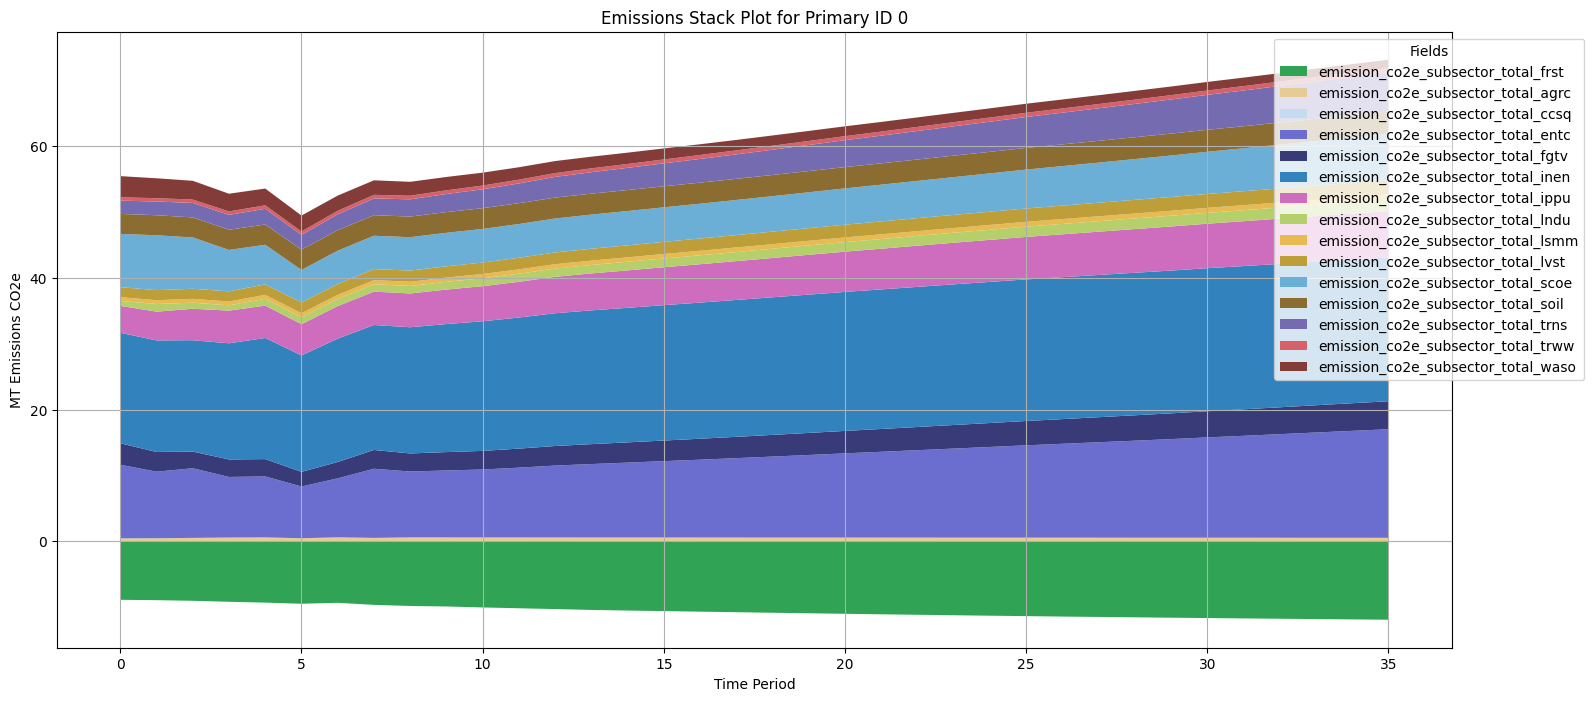

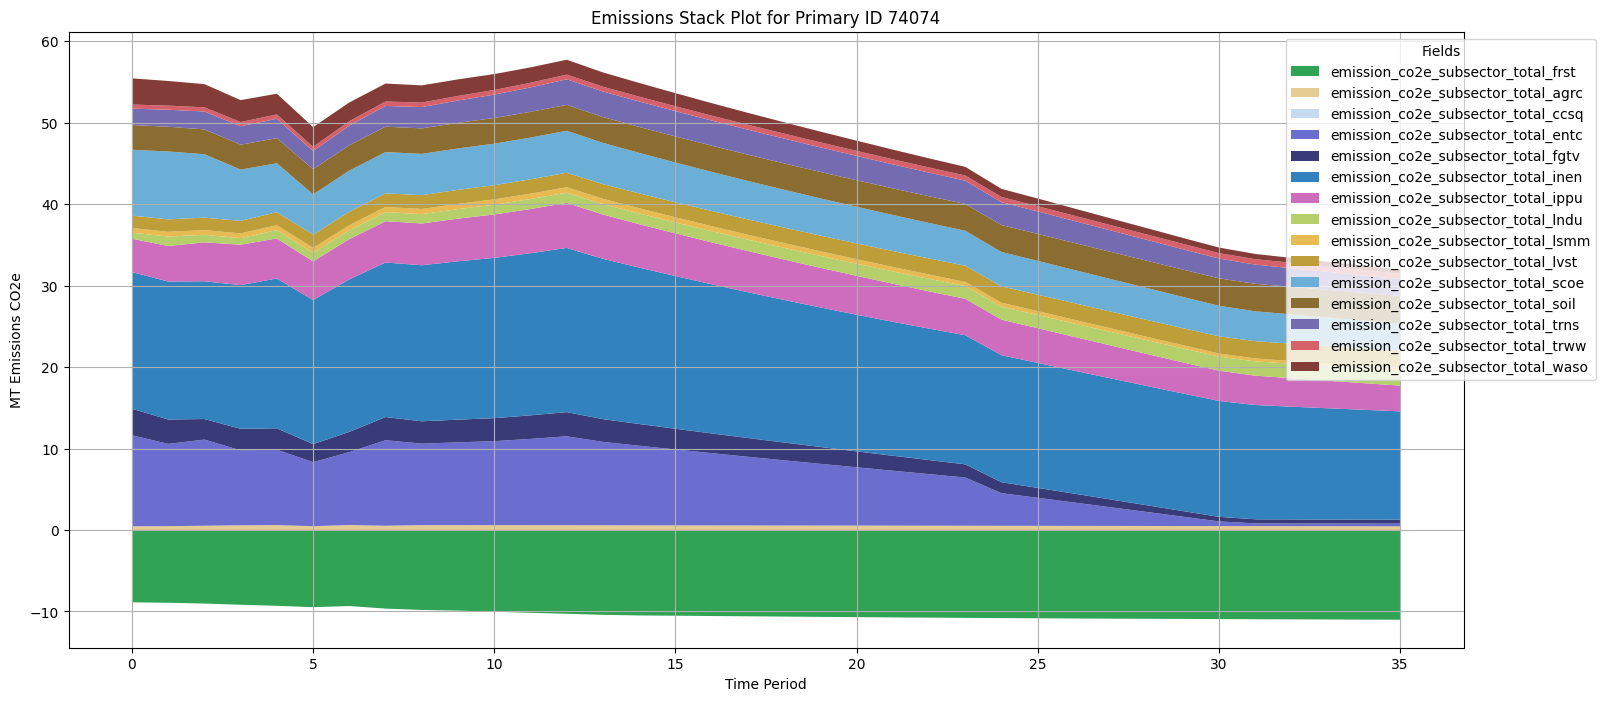

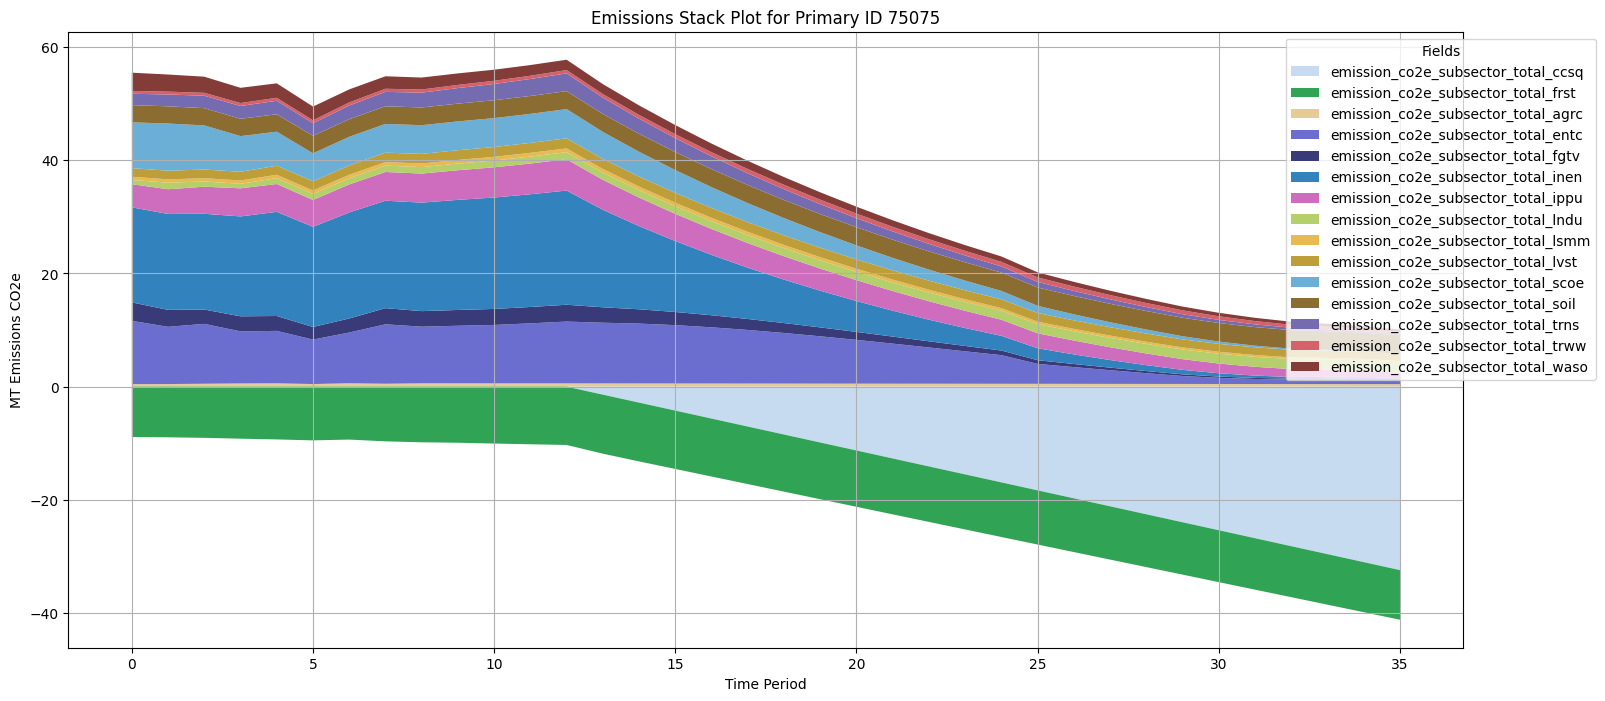

In [129]:
# Plot the emissions stack for the primary_id 0 (which is the baseline)
for primary_id in primary_ids_to_plot:

    plot_field_stack(
        df_out,
        subsector_emission_fields,
        dict_format,
        primary_id=primary_id,
        title=f"Emissions Stack Plot for Primary ID {primary_id}"
    )

In [130]:
# lvst_emission_subsectors = [
#     'emission_co2e_subsector_total_lsmm',
#     'emission_co2e_subsector_total_lvst',
#     'emission_co2e_subsector_total_agrc'
# ]
# for primary_id in primary_ids_to_plot:

#     plot_field_stack(
#         df_out,
#         lvst_emission_subsectors,
#         dict_format,
#         primary_id=primary_id,
#         title=f"Agriculture Emissions Stack Plot for Primary ID {primary_id}"
#     )

In [131]:
def get_inventory_fields_insight(inventory_df, subsector_id, ssp_out_df, primary_id=0, row_idx=7, figsize=(10,6)):

    vars_list = get_vars_by_id(inventory_df, subsector_id)
    ssp_out_df_filtered = ssp_out_df[ssp_out_df.primary_id == primary_id]
    ssp_out_df_filtered[vars_list].plot(figsize=figsize)
    print(ssp_out_df_filtered[vars_list].loc[row_idx].sort_values(ascending=False))
    print("Sum:", ssp_out_df_filtered[vars_list].loc[row_idx].sum())
    


## Check Inventory Crop Emissions

In [132]:
inventory_df = pd.read_csv("/Users/tony/Documents/sisepuede_modeling/ssp_bulgaria/ssp_modeling/output_postprocessing/data/emission_targets_bulgaria_2022.csv")
inventory_df.head()

,Subsector,Gas,Edgar_Sector,Edgar_Subsector,Edgar_Subsector_Synthetic,Vars,id,BGR,Edgar_Class
0,agrc,CH4,Agriculture,AG - Crops,AG - Crops,emission_co2e_ch4_agrc_anaerobicdom_rice:emiss...,AG - Crops - CH4,0.125150,AG - Crops:CH4
1,agrc,CO2,Agriculture,AG - Crops,AG - Crops,emission_co2e_co2_soil_soc_mineral_soils:emiss...,AG - Crops - CO2,0.094230,AG - Crops:CO2
2,agrc,N2O,Agriculture,AG - Crops,AG - Crops,emission_co2e_n2o_soil_fertilizer:emission_co2...,AG - Crops - N2O,3.402720,AG - Crops:N2O
3,lvst,CH4,Agriculture,AG - Livestock,AG - Livestock,emission_co2e_ch4_lvst_entferm_buffalo:emissio...,AG - Livestock - CH4,1.976805,AG - Livestock:CH4
4,lsmm,N2O,Agriculture,AG - Livestock,AG - Livestock,emission_co2e_n2o_lsmm_direct_anaerobic_digest...,AG - Livestock - N2O,0.306905,AG - Livestock:N2O


emission_co2e_co2_lndu_drained_organic_soils_croplands    0.074955
emission_co2e_co2_agrc_biomass_fruits                     0.011243
emission_co2e_co2_soil_lime_use                           0.006955
emission_co2e_co2_soil_soc_mineral_soils                  0.006796
emission_co2e_co2_lndu_drained_organic_soils_pastures     0.001325
emission_co2e_co2_agrc_biomass_nuts                       0.001181
emission_co2e_co2_soil_urea_use                           0.000400
emission_co2e_co2_agrc_biomass_bevs_and_spices            0.000000
emission_co2e_co2_agrc_biomass_other_woody_perennial      0.000000
Name: 7, dtype: float64
Sum: 0.1028554517529541


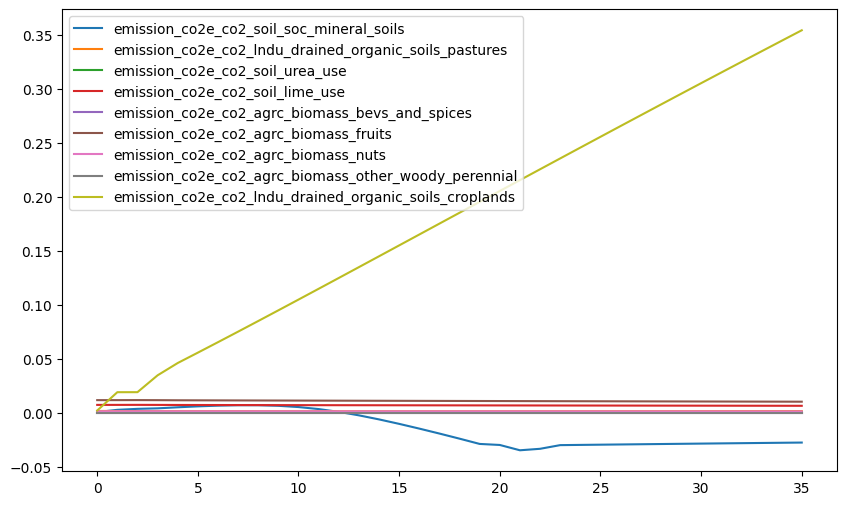

In [133]:
# co2_crop_fields = get_vars_by_id(inventory_df, "AG - Crops - CO2")
# df_out[df_out.primary_id == 0][co2_crop_fields].plot()
# print(df_out[df_out.primary_id == 0][co2_crop_fields].loc[7].sort_values(ascending=False))
# print(df_out[df_out.primary_id == 0][co2_crop_fields].loc[7].sum())

get_inventory_fields_insight(inventory_df, "AG - Crops - CO2", df_out, primary_id=0, row_idx=7)

emission_co2e_n2o_soil_organic_soils            2.289343
emission_co2e_n2o_soil_fertilizer               0.741254
emission_co2e_n2o_agrc_crop_residues            0.431857
emission_co2e_n2o_soil_paddock_pasture_range    0.075367
emission_co2e_n2o_agrc_biomass_burning          0.008834
emission_co2e_n2o_soil_mineral_soils            0.000701
Name: 7, dtype: float64
Sum: 3.547356596739631


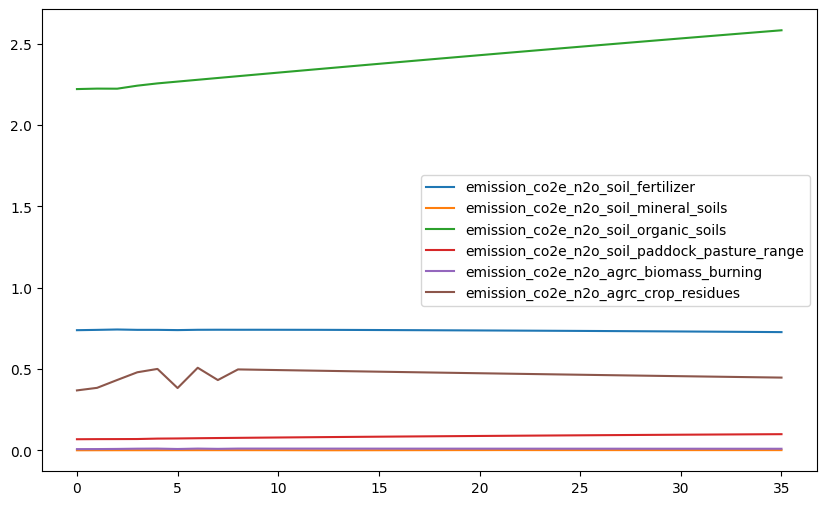

In [134]:
# n2o_crop_fields = get_vars_by_id(inventory_df, "AG - Crops - N2O")
# df_out[df_out.primary_id == 0][n2o_crop_fields].plot()
# print(df_out[df_out.primary_id == 0][n2o_crop_fields].loc[7].sort_values(ascending=False))
# print(df_out[df_out.primary_id == 0][n2o_crop_fields].loc[7].sum())

get_inventory_fields_insight(inventory_df, "AG - Crops - N2O", df_out, primary_id=0, row_idx=7)

emission_co2e_ch4_agrc_biomass_burning      0.034345
emission_co2e_ch4_agrc_anaerobicdom_rice    0.031710
Name: 7, dtype: float64
Sum: 0.066054612357823


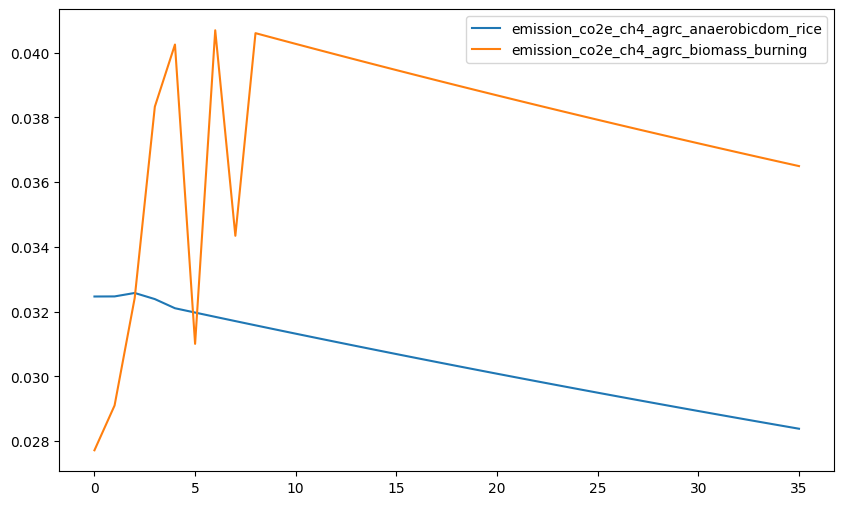

In [135]:
# ch4_crop_fields = get_vars_by_id(inventory_df, "AG - Crops - CH4")
# df_out[df_out.primary_id == 0][ch4_crop_fields].plot(figsize=(10,6))
# print(df_out[df_out.primary_id == 0][ch4_crop_fields].loc[7].sort_values(ascending=False))
# print(df_out[df_out.primary_id == 0][ch4_crop_fields].loc[7].sum())

get_inventory_fields_insight(inventory_df, "AG - Crops - CH4", df_out, primary_id=0, row_idx=7)

## Check LULUCF Inventory Emissions

In [136]:
inventory_df[inventory_df.Subsector == "frst"]

,Subsector,Gas,Edgar_Sector,Edgar_Subsector,Edgar_Subsector_Synthetic,Vars,id,BGR,Edgar_Class
33,frst,CO2,"Land Use, Land Use Change, and Forestry",LULUCF - Forest Land,LULUCF - Forest Land - CO2,emission_co2e_co2_frst_sequestration_mangroves...,LULUCF - Forest Land - CO2,-8.34498,LULUCF - Forest Land:CO2
34,frst,CH4,"Land Use, Land Use Change, and Forestry",LULUCF - Forest Land,LULUCF - Forest Land - CH4,emission_co2e_ch4_frst_methane_mangroves:emiss...,LULUCF - Forest Land - CH4,0.00000,LULUCF - Forest Land:CH4
35,frst,CO2,"Land Use, Land Use Change, and Forestry",LULUCF - HWP,LULUCF - HWP - CO2,emission_co2e_co2_frst_harvested_wood_products,LULUCF - HWP - CO2,-0.97025,LULUCF - HWP:CO2


emission_co2e_co2_frst_forest_fires               0.000643
emission_co2e_co2_frst_sequestration_mangroves   -0.025983
emission_co2e_co2_frst_sequestration_primary     -0.035812
emission_co2e_co2_frst_sequestration_secondary   -8.676195
Name: 7, dtype: float64
Sum: -8.737346594298694


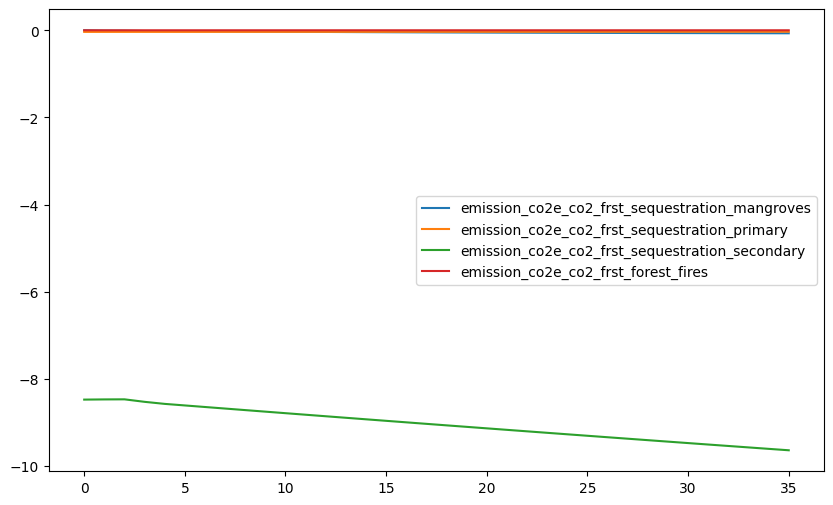

In [137]:
get_inventory_fields_insight(inventory_df, "LULUCF - Forest Land - CO2", df_out, primary_id=0, row_idx=7)

emission_co2e_ch4_frst_methane_secondary    0.001116
emission_co2e_ch4_frst_methane_primary      0.000010
emission_co2e_ch4_frst_methane_mangroves    0.000003
Name: 7, dtype: float64
Sum: 0.0011286557754139257


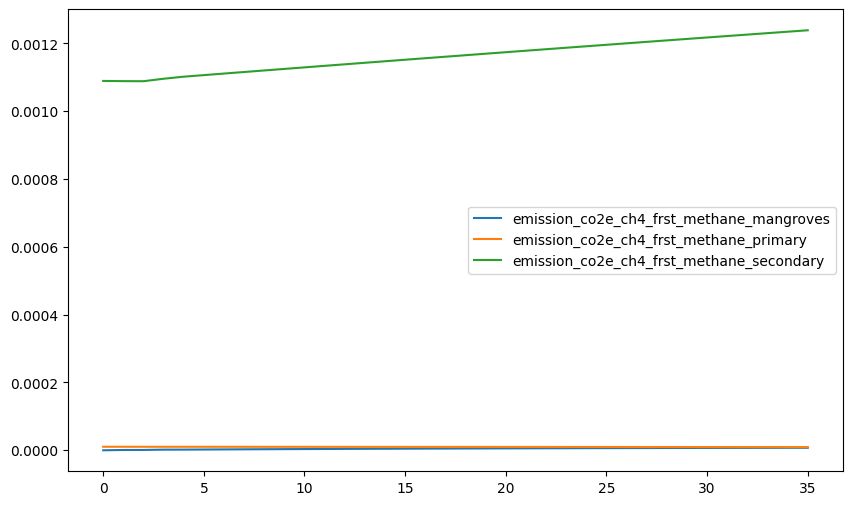

In [138]:
get_inventory_fields_insight(inventory_df, "LULUCF - Forest Land - CH4", df_out, primary_id=0, row_idx=7)

emission_co2e_co2_frst_harvested_wood_products   -0.915894
Name: 7, dtype: float64
Sum: -0.915894345833142


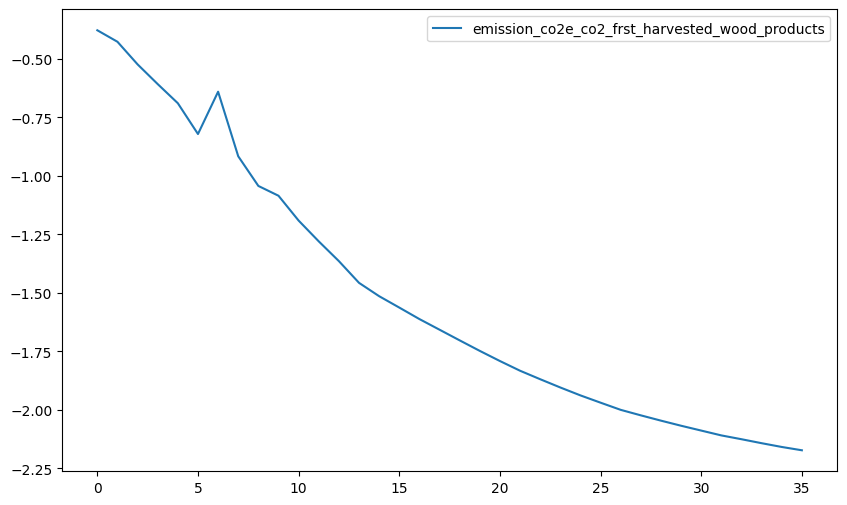

In [139]:
get_inventory_fields_insight(inventory_df, "LULUCF - HWP - CO2", df_out, primary_id=0, row_idx=7)

In [140]:
inventory_df[inventory_df.Subsector == "lndu"]

,Subsector,Gas,Edgar_Sector,Edgar_Subsector,Edgar_Subsector_Synthetic,Vars,id,BGR,Edgar_Class
36,lndu,CH4,"Land Use, Land Use Change, and Forestry",LULUCF - Wetlands,LULUCF - Wetlands - CH4,emission_co2e_ch4_lndu_wetlands,LULUCF - Wetlands - CH4,0.00000,LULUCF - Wetlands:CH4
37,lndu,CO2,"Land Use, Land Use Change, and Forestry",LULUCF - Cropland,LULUCF - Cropland - CO2,emission_co2e_co2_lndu_conversion_forests_mang...,LULUCF - Cropland - CO2,0.35592,LULUCF - Cropland:CO2
38,lndu,CO2,"Land Use, Land Use Change, and Forestry",LULUCF - Grassland,LULUCF - Grassland - CO2,emission_co2e_co2_lndu_conversion_forests_mang...,LULUCF - Grassland - CO2,-0.83481,LULUCF - Grassland:CO2
39,lndu,CO2,"Land Use, Land Use Change, and Forestry",LULUCF - Wetlands,LULUCF - Wetlands - CO2,emission_co2e_co2_lndu_conversion_forests_mang...,LULUCF - Wetlands - CO2,0.08098,LULUCF - Wetlands:CO2
40,lndu,CO2,"Land Use, Land Use Change, and Forestry",LULUCF - Settlements,LULUCF - Settlements - CO2,emission_co2e_co2_lndu_conversion_forests_mang...,LULUCF - Settlements - CO2,0.17311,LULUCF - Settlements:CO2
41,lndu,CO2,"Land Use, Land Use Change, and Forestry",LULUCF - Other Land,LULUCF - Other Land - CO2,emission_co2e_co2_lndu_biomass_sequestration_o...,LULUCF - Other Land - CO2,0.00000,LULUCF - Other Land:CO2


emission_co2e_co2_lndu_conversion_forests_secondary_to_settlements    0.170679
emission_co2e_co2_lndu_conversion_forests_mangroves_to_settlements    0.000000
emission_co2e_co2_lndu_conversion_forests_primary_to_settlements      0.000000
emission_co2e_co2_lndu_conversion_croplands_to_settlements            0.000000
emission_co2e_co2_lndu_conversion_flooded_to_settlements              0.000000
emission_co2e_co2_lndu_conversion_grasslands_to_settlements           0.000000
emission_co2e_co2_lndu_conversion_other_to_settlements                0.000000
emission_co2e_co2_lndu_conversion_pastures_to_settlements             0.000000
emission_co2e_co2_lndu_conversion_settlements_to_settlements          0.000000
emission_co2e_co2_lndu_conversion_shrublands_to_settlements           0.000000
emission_co2e_co2_lndu_conversion_wetlands_to_settlements             0.000000
emission_co2e_co2_lndu_biomass_sequestration_settlements             -0.000000
Name: 7, dtype: float64
Sum: 0.1706790372588102


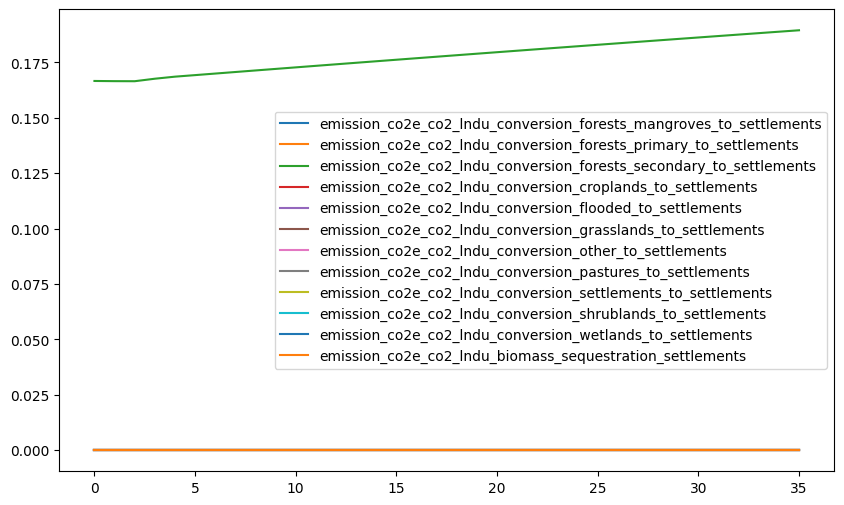

In [141]:
get_inventory_fields_insight(inventory_df, "LULUCF - Settlements - CO2", df_out, primary_id=0, row_idx=7)

emission_co2e_co2_lndu_conversion_forests_secondary_to_wetlands    0.07832
emission_co2e_co2_lndu_conversion_forests_mangroves_to_wetlands    0.00000
emission_co2e_co2_lndu_conversion_forests_primary_to_wetlands      0.00000
emission_co2e_co2_lndu_conversion_croplands_to_wetlands            0.00000
emission_co2e_co2_lndu_conversion_flooded_to_wetlands              0.00000
emission_co2e_co2_lndu_conversion_grasslands_to_wetlands           0.00000
emission_co2e_co2_lndu_conversion_other_to_wetlands                0.00000
emission_co2e_co2_lndu_conversion_pastures_to_wetlands             0.00000
emission_co2e_co2_lndu_conversion_settlements_to_wetlands          0.00000
emission_co2e_co2_lndu_conversion_shrublands_to_wetlands           0.00000
emission_co2e_co2_lndu_conversion_wetlands_to_wetlands             0.00000
emission_co2e_co2_lndu_biomass_sequestration_wetlands             -0.00000
Name: 7, dtype: float64
Sum: 0.0783202256170175


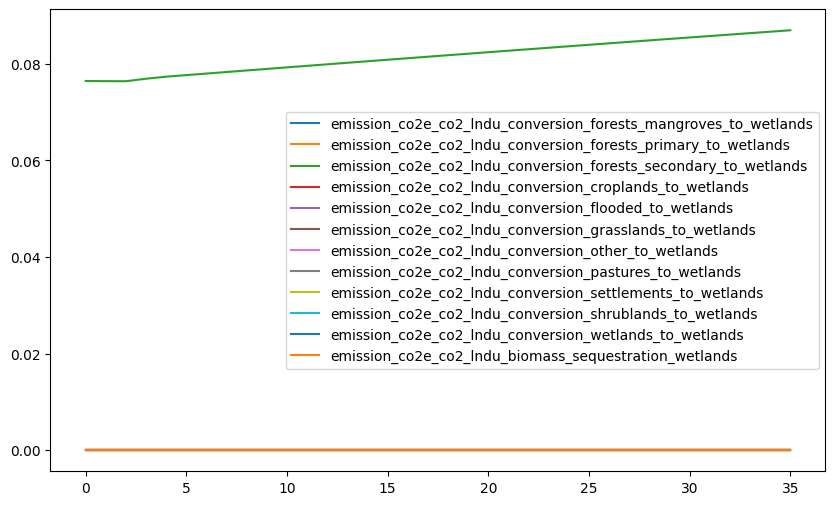

In [142]:
get_inventory_fields_insight(inventory_df, "LULUCF - Wetlands - CO2", df_out, primary_id=0, row_idx=7)

emission_co2e_co2_lndu_conversion_forests_primary_to_grasslands      0.000652
emission_co2e_co2_lndu_conversion_forests_mangroves_to_grasslands    0.000000
emission_co2e_co2_lndu_conversion_forests_secondary_to_grasslands    0.000000
emission_co2e_co2_lndu_conversion_croplands_to_grasslands            0.000000
emission_co2e_co2_lndu_conversion_flooded_to_grasslands              0.000000
emission_co2e_co2_lndu_conversion_grasslands_to_grasslands           0.000000
emission_co2e_co2_lndu_conversion_other_to_grasslands                0.000000
emission_co2e_co2_lndu_conversion_pastures_to_grasslands             0.000000
emission_co2e_co2_lndu_conversion_settlements_to_grasslands          0.000000
emission_co2e_co2_lndu_conversion_shrublands_to_grasslands           0.000000
emission_co2e_co2_lndu_conversion_wetlands_to_grasslands             0.000000
emission_co2e_co2_lndu_biomass_sequestration_grasslands             -0.000000
emission_co2e_co2_lndu_biomass_sequestration_pastures           

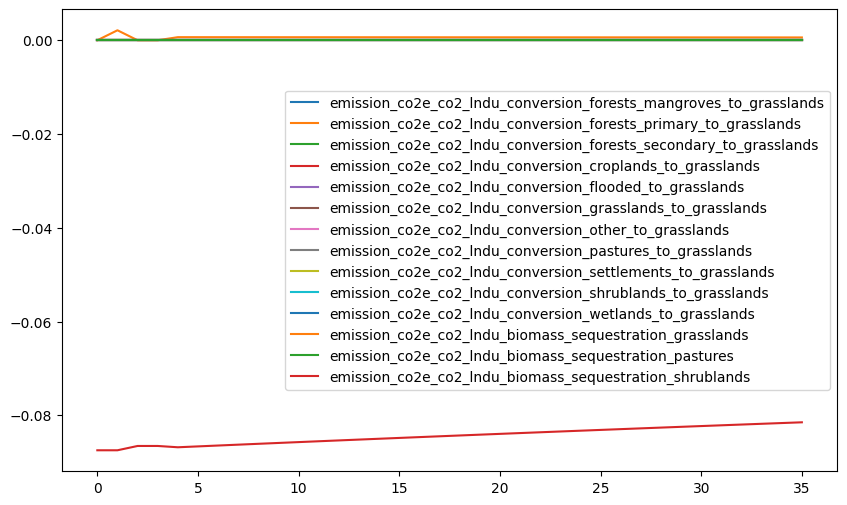

In [143]:
get_inventory_fields_insight(inventory_df, "LULUCF - Grassland - CO2", df_out, primary_id=0, row_idx=7)

emission_co2e_co2_lndu_conversion_forests_secondary_to_croplands    0.243827
emission_co2e_co2_lndu_conversion_forests_primary_to_croplands      0.057469
emission_co2e_co2_lndu_conversion_shrublands_to_croplands           0.045745
emission_co2e_co2_lndu_conversion_forests_mangroves_to_croplands    0.023467
emission_co2e_co2_lndu_conversion_grasslands_to_croplands           0.017756
emission_co2e_co2_lndu_conversion_pastures_to_croplands             0.002542
emission_co2e_co2_lndu_conversion_wetlands_to_croplands             0.001327
emission_co2e_co2_lndu_conversion_other_to_croplands                0.000000
emission_co2e_co2_lndu_conversion_settlements_to_croplands          0.000000
Name: 7, dtype: float64
Sum: 0.3921332515859285


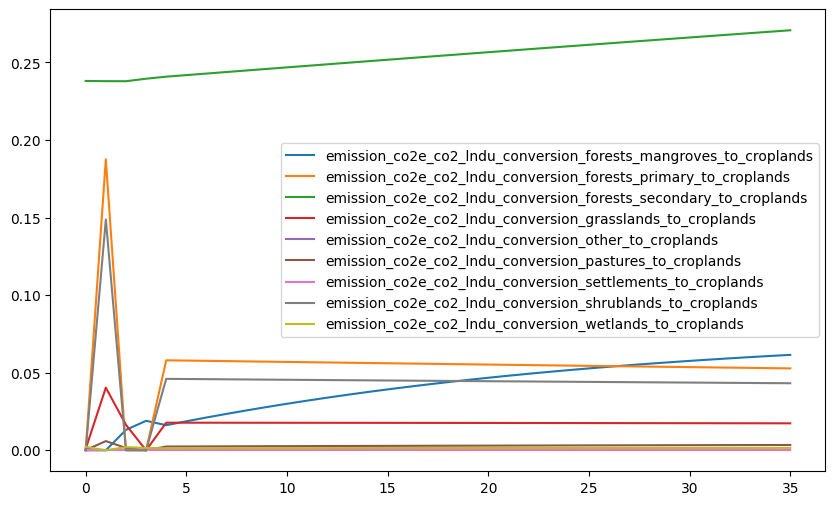

In [144]:
get_inventory_fields_insight(inventory_df, "LULUCF - Cropland - CO2", df_out, primary_id=0, row_idx=7)

emission_co2e_ch4_lndu_wetlands    0.000084
Name: 7, dtype: float64
Sum: 8.353264005000365e-05


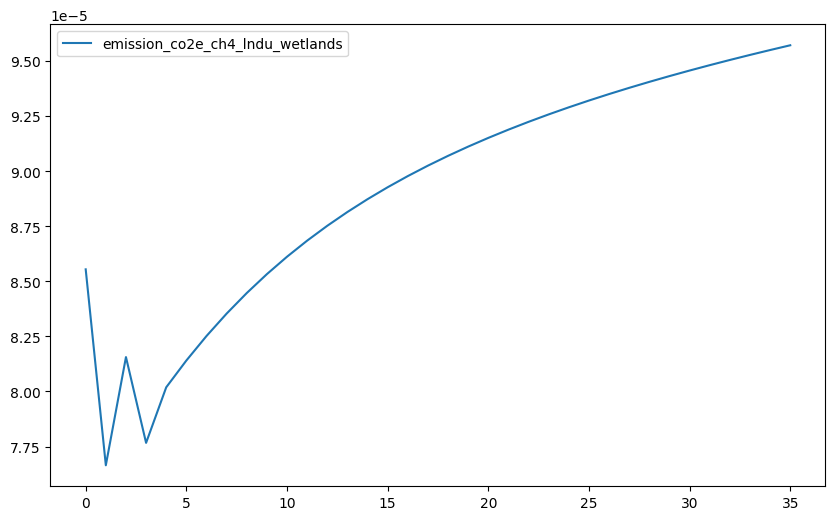

In [145]:
get_inventory_fields_insight(inventory_df, "LULUCF - Wetlands - CH4", df_out, primary_id=0, row_idx=7)

emission_co2e_co2_lndu_biomass_sequestration_other   -0.0
Name: 7, dtype: float64
Sum: 0.0


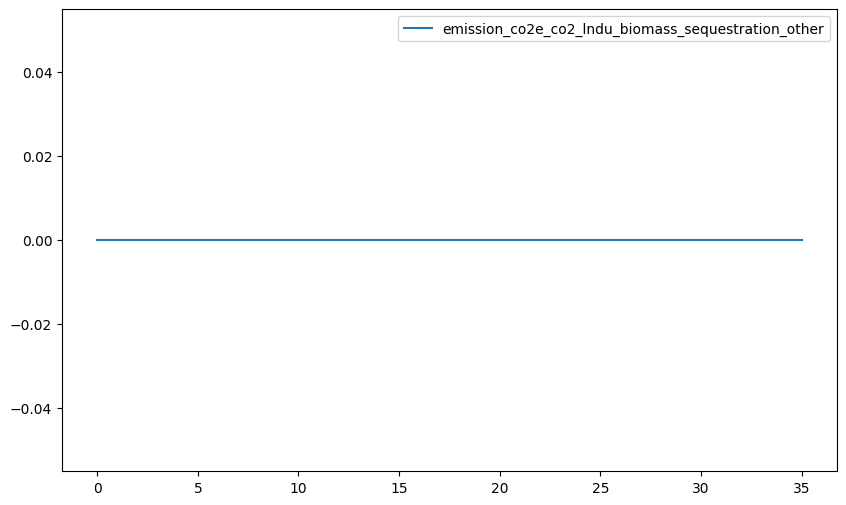

In [146]:
get_inventory_fields_insight(inventory_df, "LULUCF - Other Land - CO2", df_out, primary_id=0, row_idx=7)

## Check Waste inventory emissions

emission_co2e_ch4_waso_open_dump_chemical_industrial     0.567021
emission_co2e_ch4_waso_landfilled_chemical_industrial    0.363982
emission_co2e_ch4_waso_open_dump_food                    0.337837
emission_co2e_ch4_waso_landfilled_food                   0.274820
emission_co2e_ch4_waso_open_dump_yard                    0.144612
emission_co2e_ch4_waso_open_dump_paper                   0.140116
emission_co2e_ch4_waso_landfilled_yard                   0.110258
emission_co2e_ch4_waso_landfilled_paper                  0.110063
emission_co2e_ch4_waso_open_dump_nappies                 0.036596
emission_co2e_ch4_waso_landfilled_nappies                0.028603
emission_co2e_ch4_waso_open_dump_textiles                0.025344
emission_co2e_ch4_waso_landfilled_textiles               0.019285
emission_co2e_ch4_waso_open_dump_wood                    0.008127
emission_co2e_ch4_waso_landfilled_wood                   0.005681
emission_co2e_ch4_waso_compost_food                      0.004925
emission_c

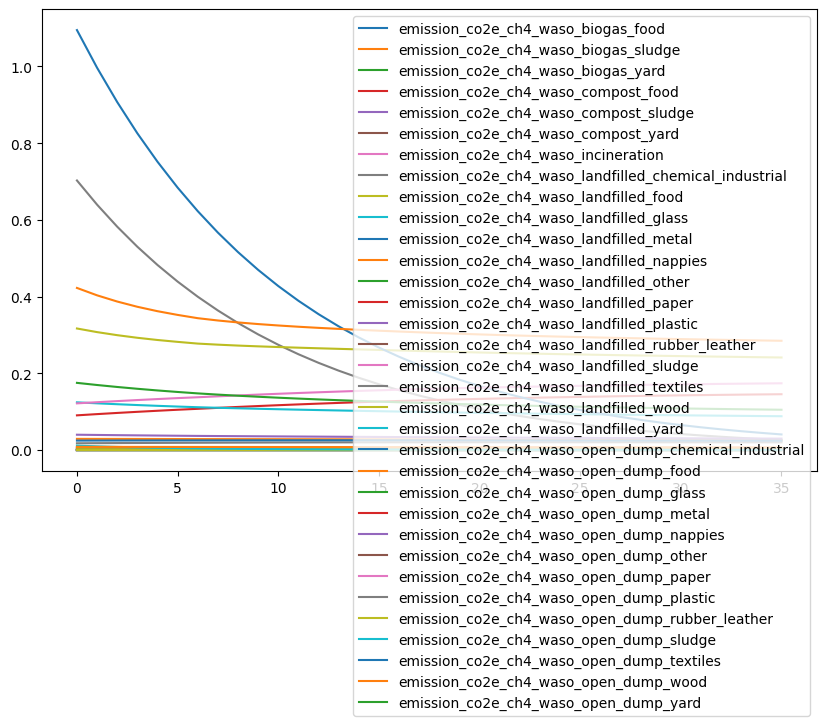

In [147]:
get_inventory_fields_insight(inventory_df, "Waste - Solid Waste - CH4", df_out, primary_id=0, row_idx=7)

emission_co2e_co2_waso_incineration    0.012585
Name: 7, dtype: float64
Sum: 0.0125851747400874


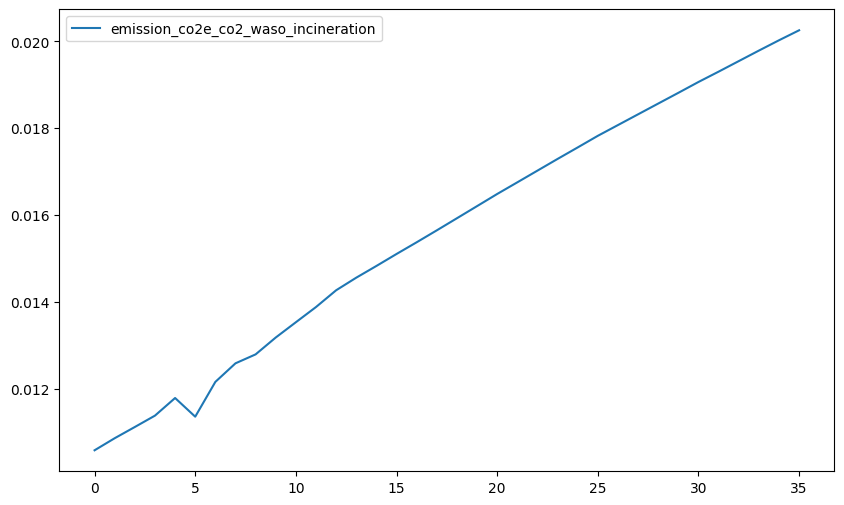

In [148]:
get_inventory_fields_insight(inventory_df, "Waste - Solid Waste - CO2", df_out, primary_id=0, row_idx=7)

emission_co2e_n2o_waso_compost_food      0.002968
emission_co2e_n2o_waso_compost_yard      0.001429
emission_co2e_n2o_waso_compost_sludge    0.000264
emission_co2e_n2o_waso_incineration      0.000001
Name: 7, dtype: float64
Sum: 0.004662220243095955


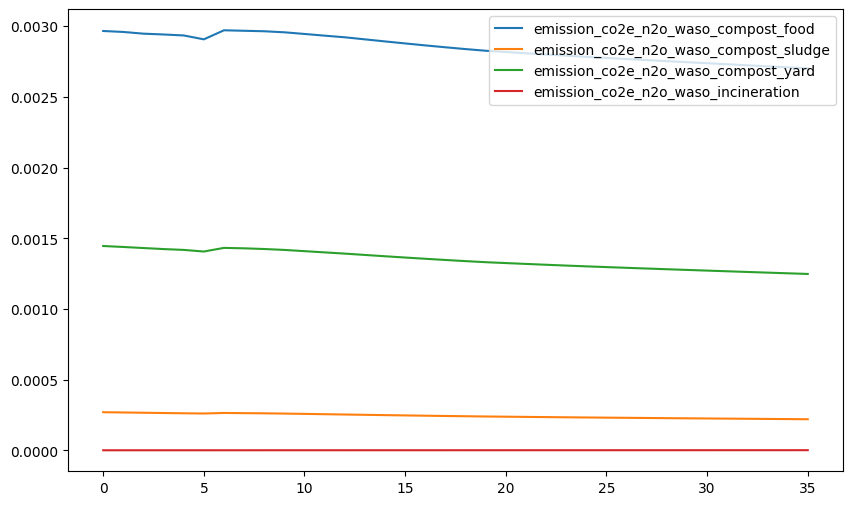

In [149]:
get_inventory_fields_insight(inventory_df, "Waste - Solid Waste - N2O", df_out, primary_id=0, row_idx=7)

emission_co2e_ch4_trww_untreated_no_sewerage_treatment          0.264133
emission_co2e_ch4_trww_untreated_with_sewerage_treatment        0.254077
emission_co2e_ch4_trww_treated_advanced_aerobic_treatment       0.000000
emission_co2e_ch4_trww_treated_advanced_anaerobic_treatment     0.000000
emission_co2e_ch4_trww_treated_latrine_improved_treatment       0.000000
emission_co2e_ch4_trww_treated_latrine_unimproved_treatment     0.000000
emission_co2e_ch4_trww_treated_primary_treatment                0.000000
emission_co2e_ch4_trww_treated_secondary_aerobic_treatment      0.000000
emission_co2e_ch4_trww_treated_secondary_anaerobic_treatment    0.000000
emission_co2e_ch4_trww_treated_septic_treatment                 0.000000
Name: 7, dtype: float64
Sum: 0.5182096104856566


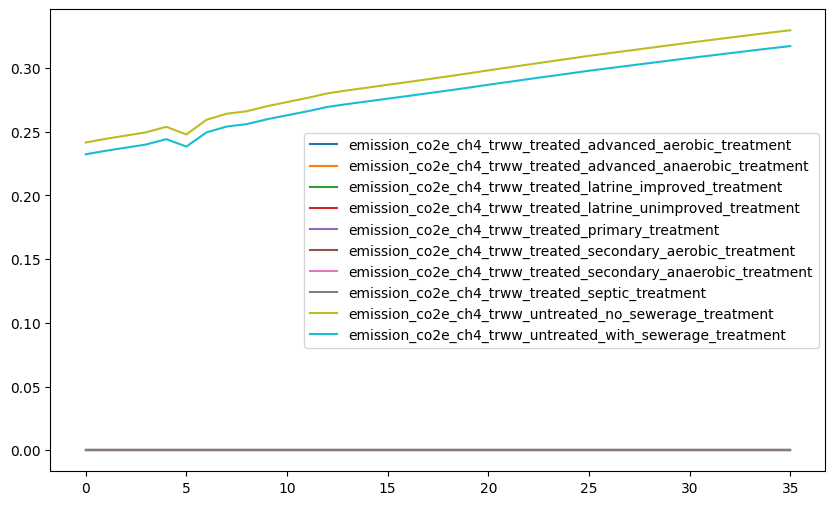

In [150]:
get_inventory_fields_insight(inventory_df, "Waste - Wastewater Treatment - CH4", df_out, primary_id=0, row_idx=7)

emission_co2e_n2o_trww_untreated_with_sewerage_treatment        0.010437
emission_co2e_n2o_trww_untreated_no_sewerage_treatment          0.008587
emission_co2e_n2o_trww_untreated_no_sewerage_effluent           0.008587
emission_co2e_n2o_trww_untreated_with_sewerage_effluent         0.001044
emission_co2e_n2o_trww_treated_advanced_aerobic_treatment       0.000000
emission_co2e_n2o_trww_treated_septic_treatment                 0.000000
emission_co2e_n2o_trww_treated_septic_effluent                  0.000000
emission_co2e_n2o_trww_treated_secondary_anaerobic_treatment    0.000000
emission_co2e_n2o_trww_treated_secondary_anaerobic_effluent     0.000000
emission_co2e_n2o_trww_treated_secondary_aerobic_treatment      0.000000
emission_co2e_n2o_trww_treated_advanced_aerobic_effluent        0.000000
emission_co2e_n2o_trww_treated_primary_treatment                0.000000
emission_co2e_n2o_trww_treated_primary_effluent                 0.000000
emission_co2e_n2o_trww_treated_latrine_unimproved_t

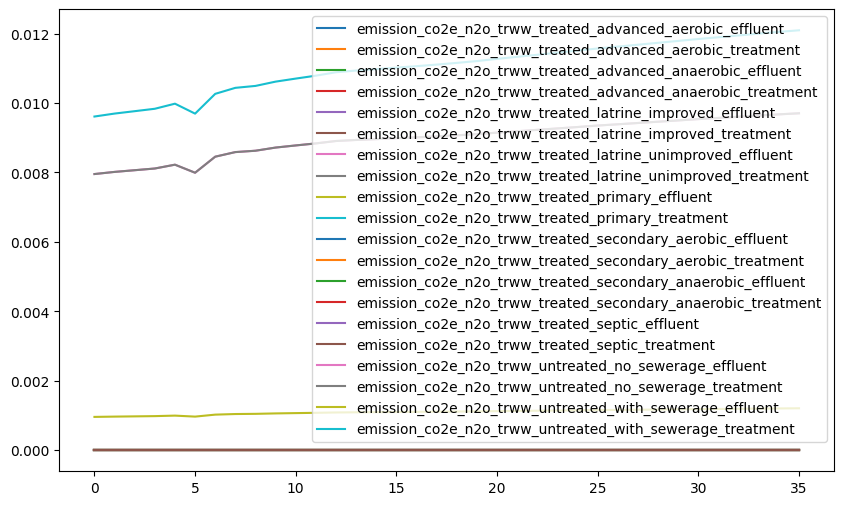

In [151]:
get_inventory_fields_insight(inventory_df, "Waste - Wastewater Treatment - N2O", df_out, primary_id=0, row_idx=7)

## Check Inventory IPPU Emissions

In [152]:
inventory_df[inventory_df.Subsector == "ippu"].head()

,Subsector,Gas,Edgar_Sector,Edgar_Subsector,Edgar_Subsector_Synthetic,Vars,id,BGR,Edgar_Class
26,ippu,CH4,Industrial Processes,IN - Industrial Processes,IN - Industrial Processes,emission_co2e_ch4_ippu_production_chemicals:em...,IN - Industrial Processes - CH4,0.00000,IN - Industrial Processes:CH4
27,ippu,CO2,Industrial Processes,IN - Industrial Processes,IN - Industrial Processes,emission_co2e_co2_ippu_product_use_product_use...,IN - Industrial Processes - CO2,3.77808,IN - Industrial Processes:CO2
28,ippu,HFC,Industrial Processes,IN - Industrial Processes,IN - Industrial Processes,emission_co2e_hfcs_ippu_product_use_product_us...,IN - Industrial Processes - HFC,0.70185,IN - Industrial Processes:HFC
29,ippu,N2O,Industrial Processes,IN - Industrial Processes,IN - Industrial Processes,emission_co2e_n2o_ippu_production_chemicals:em...,IN - Industrial Processes - N2O,0.07987,IN - Industrial Processes:N2O
30,ippu,OTHER_FCS,Industrial Processes,IN - Industrial Processes,IN - Industrial Processes,emission_co2e_other_fcs_ippu_product_use_produ...,IN - Industrial Processes - OTHER_FCS,0.00000,IN - Industrial Processes:OTHER_FCS


emission_co2e_co2_ippu_production_metals                       1.680922
emission_co2e_co2_ippu_production_cement                       1.076238
emission_co2e_co2_ippu_production_lime_and_carbonite           0.694179
emission_co2e_co2_ippu_production_plastic                      0.042714
emission_co2e_co2_ippu_product_use_product_use_lubricants      0.019140
emission_co2e_co2_ippu_product_use_product_use_paraffin_wax    0.016843
emission_co2e_co2_ippu_production_glass                        0.011860
emission_co2e_co2_ippu_production_chemicals                    0.005714
emission_co2e_co2_ippu_product_use_product_use_other           0.001215
emission_co2e_co2_ippu_production_paper                        0.000000
emission_co2e_co2_ippu_production_product_use_lubricants       0.000000
emission_co2e_co2_ippu_production_product_use_paraffin_wax     0.000000
Name: 7, dtype: float64
3.548823782539753


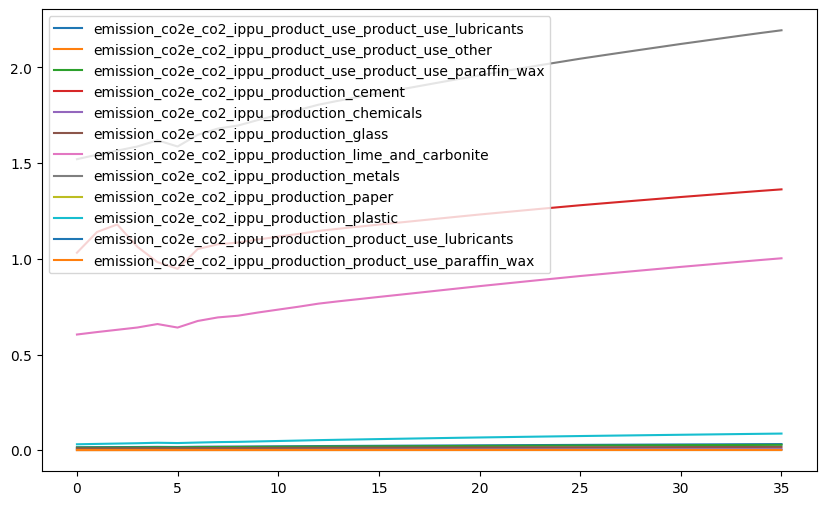

In [153]:
co2_ippu_fields = get_vars_by_id(inventory_df, "IN - Industrial Processes - CO2")

df_out[df_out.primary_id == 0][co2_ippu_fields].plot(figsize=(10,6))
print(df_out[df_out.primary_id == 0][co2_ippu_fields].loc[7].sort_values(ascending=False))
print(df_out[df_out.primary_id == 0][co2_ippu_fields].loc[7].sum())

emission_co2e_n2o_ippu_production_chemicals                      0.068738
emission_co2e_n2o_ippu_production_other_product_manufacturing    0.004759
emission_co2e_n2o_ippu_production_paper                          0.000000
emission_co2e_n2o_ippu_production_plastic                        0.000000
Name: 7, dtype: float64
0.0734963427853893


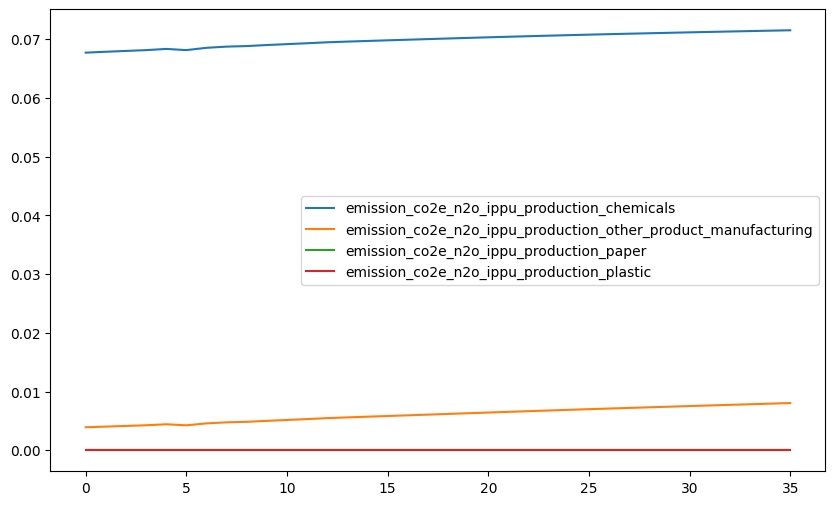

In [154]:
n2o_ippu_fields = get_vars_by_id(inventory_df, "IN - Industrial Processes - N2O")

df_out[df_out.primary_id == 0][n2o_ippu_fields].plot(figsize=(10,6))
print(df_out[df_out.primary_id == 0][n2o_ippu_fields].loc[7].sort_values(ascending=False))
print(df_out[df_out.primary_id == 0][n2o_ippu_fields].loc[7].sum())

emission_co2e_hfcs_ippu_production_electronics                       0.295141
emission_co2e_hfcs_ippu_product_use_product_use_ods_refrigeration    0.236649
emission_co2e_hfcs_ippu_product_use_product_use_ods_other            0.176863
emission_co2e_hfcs_ippu_production_chemicals                         0.000000
emission_co2e_hfcs_ippu_production_metals                            0.000000
Name: 7, dtype: float64
0.7086529657059996


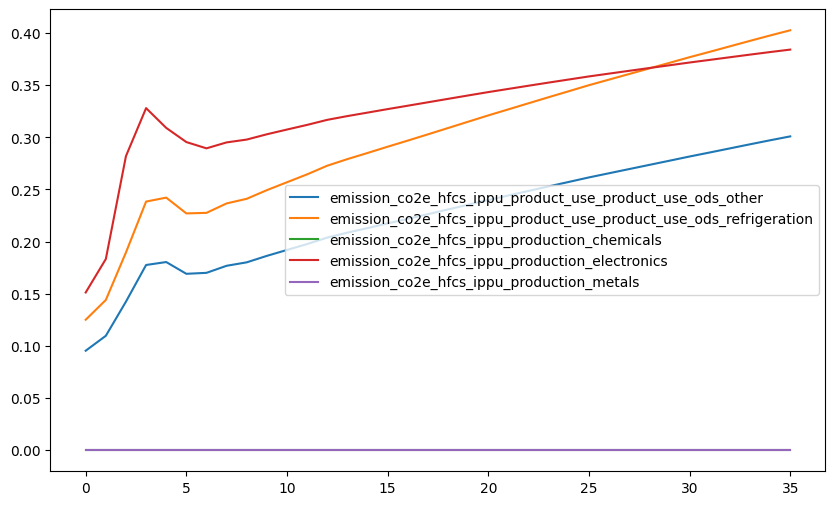

In [155]:
hfc_ippu_fields = get_vars_by_id(inventory_df, "IN - Industrial Processes - HFC")

df_out[df_out.primary_id == 0][hfc_ippu_fields].plot(figsize=(10,6))
print(df_out[df_out.primary_id == 0][hfc_ippu_fields].loc[7].sort_values(ascending=False))
print(df_out[df_out.primary_id == 0][hfc_ippu_fields].loc[7].sum())

emission_co2e_sf6_ippu_production_other_product_manufacturing    0.021303
emission_co2e_sf6_ippu_production_electronics                    0.001703
emission_co2e_sf6_ippu_production_chemicals                      0.000000
emission_co2e_sf6_ippu_production_metals                         0.000000
Name: 7, dtype: float64
0.0230055842928284


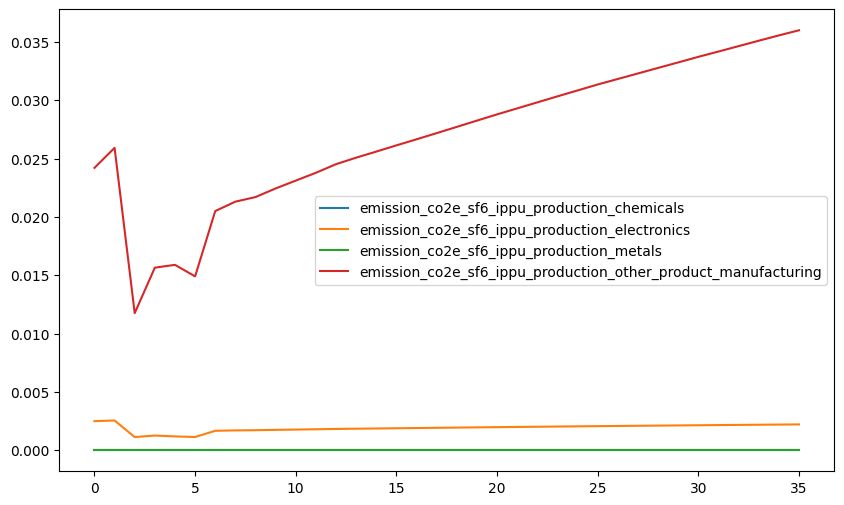

In [156]:
sf6_ippu_fields = get_vars_by_id(inventory_df, "IN - Industrial Processes - SF6")

df_out[df_out.primary_id == 0][sf6_ippu_fields].plot(figsize=(10,6))
print(df_out[df_out.primary_id == 0][sf6_ippu_fields].loc[7].sort_values(ascending=False))
print(df_out[df_out.primary_id == 0][sf6_ippu_fields].loc[7].sum())

emission_co2e_ch4_ippu_production_metals       0.004361
emission_co2e_ch4_ippu_production_plastic      0.003286
emission_co2e_ch4_ippu_production_chemicals    0.000218
emission_co2e_ch4_ippu_production_paper        0.000000
Name: 7, dtype: float64
0.0078645468884501


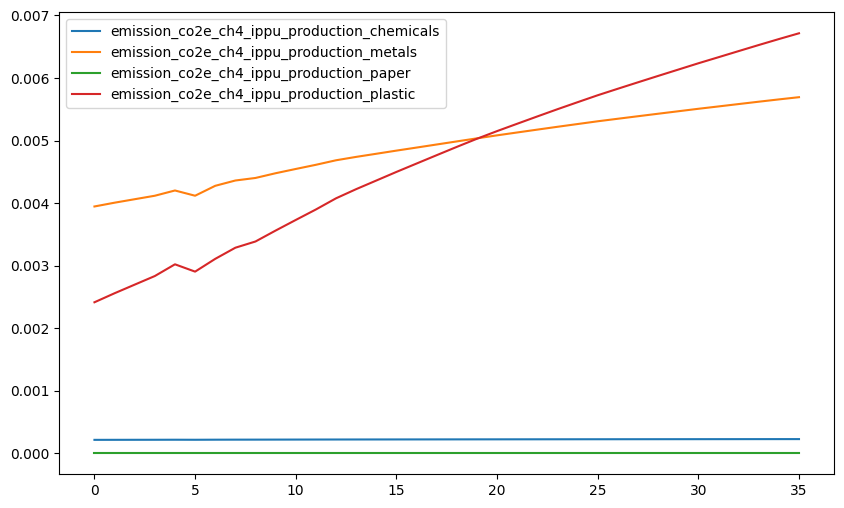

In [157]:
ch4_ippu_fields = get_vars_by_id(inventory_df, "IN - Industrial Processes - CH4")

df_out[df_out.primary_id == 0][ch4_ippu_fields].plot(figsize=(10,6))
print(df_out[df_out.primary_id == 0][ch4_ippu_fields].loc[7].sort_values(ascending=False))
print(df_out[df_out.primary_id == 0][ch4_ippu_fields].loc[7].sum())

## Check Livestock inventory emissions

In [158]:
inventory_df[inventory_df.Subsector == "lsmm"].head()

,Subsector,Gas,Edgar_Sector,Edgar_Subsector,Edgar_Subsector_Synthetic,Vars,id,BGR,Edgar_Class
4,lsmm,N2O,Agriculture,AG - Livestock,AG - Livestock,emission_co2e_n2o_lsmm_direct_anaerobic_digest...,AG - Livestock - N2O,0.306905,AG - Livestock:N2O


In [159]:
ch4_lvst_fields = get_vars_by_id(inventory_df, "AG - Livestock - CH4")
n2o_lvst_fields = get_vars_by_id(inventory_df, "AG - Livestock - N2O")

emission_co2e_ch4_lvst_entferm_cattle_dairy       0.737264
emission_co2e_ch4_lvst_entferm_cattle_nondairy    0.462386
emission_co2e_ch4_lvst_entferm_sheep              0.331127
emission_co2e_ch4_lsmm_liquid_slurry              0.252827
emission_co2e_ch4_lvst_entferm_goats              0.065132
emission_co2e_ch4_lsmm_storage_solid              0.041826
emission_co2e_ch4_lvst_entferm_horses             0.026711
emission_co2e_ch4_lvst_entferm_pigs               0.021232
emission_co2e_ch4_lvst_entferm_buffalo            0.019778
emission_co2e_ch4_lsmm_anaerobic_lagoon           0.014424
emission_co2e_ch4_lvst_entferm_mules              0.006895
emission_co2e_ch4_lsmm_paddock_pasture_range      0.003719
emission_co2e_ch4_lsmm_poultry_manure             0.002497
emission_co2e_ch4_lsmm_dry_lot                    0.000945
emission_co2e_ch4_lsmm_daily_spread               0.000427
emission_co2e_ch4_lsmm_anaerobic_digester         0.000000
emission_co2e_ch4_lsmm_composting                 0.0000

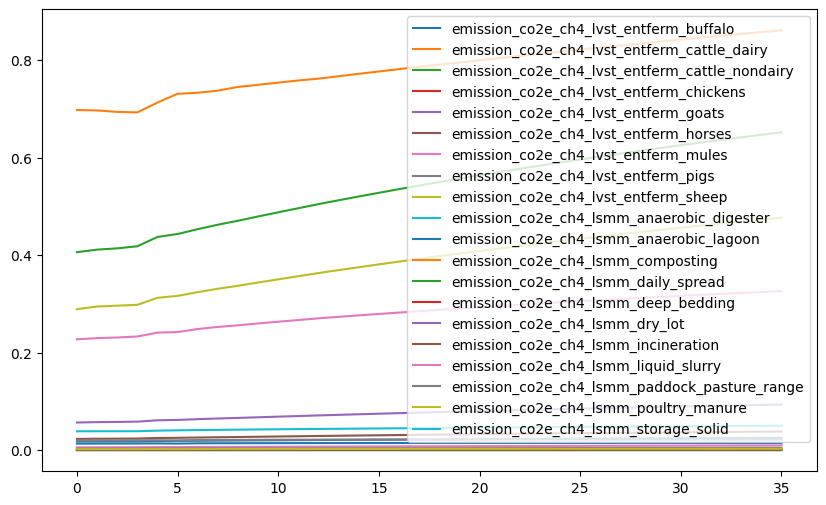

In [160]:
df_out[df_out.primary_id == 0][ch4_lvst_fields].plot(figsize=(10,6))
print(df_out[df_out.primary_id == 0][ch4_lvst_fields].loc[7].sort_values(ascending=False))
print(df_out[df_out.primary_id == 0][ch4_lvst_fields].loc[7].sum())

emission_co2e_n2o_lsmm_direct_storage_solid              0.171843
emission_co2e_n2o_lsmm_indirect_storage_solid            0.056694
emission_co2e_n2o_lsmm_direct_liquid_slurry              0.028981
emission_co2e_n2o_lsmm_direct_dry_lot                    0.024355
emission_co2e_n2o_lsmm_indirect_liquid_slurry            0.020494
emission_co2e_n2o_lsmm_direct_poultry_manure             0.002978
emission_co2e_n2o_lsmm_indirect_dry_lot                  0.002897
emission_co2e_n2o_lsmm_indirect_poultry_manure           0.002074
emission_co2e_n2o_lsmm_indirect_anaerobic_lagoon         0.000968
emission_co2e_n2o_lsmm_indirect_daily_spread             0.000829
emission_co2e_n2o_lsmm_indirect_paddock_pasture_range    0.000000
emission_co2e_n2o_lsmm_indirect_incineration             0.000000
emission_co2e_n2o_lsmm_indirect_deep_bedding             0.000000
emission_co2e_n2o_lsmm_direct_anaerobic_digester         0.000000
emission_co2e_n2o_lsmm_indirect_composting               0.000000
emission_c

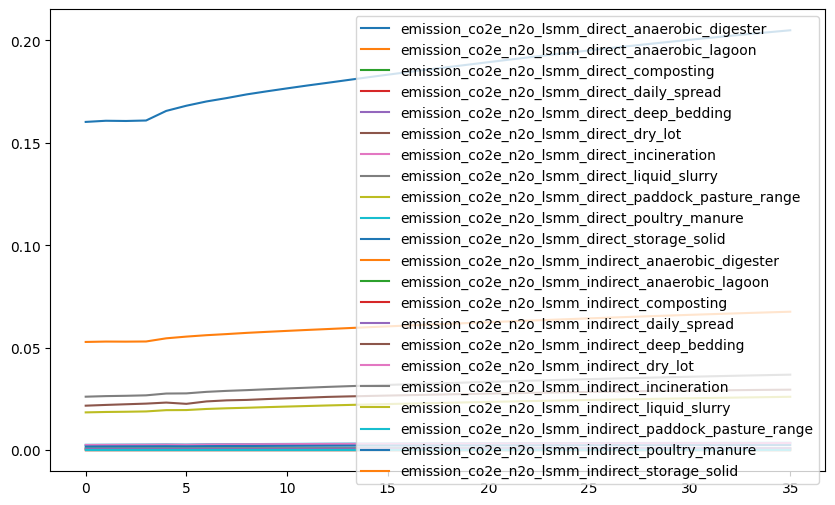

In [161]:
df_out[df_out.primary_id == 0][n2o_lvst_fields].plot(figsize=(10,6))
print(df_out[df_out.primary_id == 0][n2o_lvst_fields].loc[7].sort_values(ascending=False))
print(df_out[df_out.primary_id == 0][n2o_lvst_fields].loc[7].sum())

### LNDU Area check


In [162]:
# lndu_area_type_fields = matt.get_variable("Land Use Area").fields
# for primary_id in primary_ids_to_plot:

#     plot_field_stack(
#         df_out,
#         ["area_lndu_forests_secondary"],
#         dict_format,
#         primary_id=primary_id,
#         title=f"Land Use Area Stack Plot for Primary ID {primary_id}"
#     )


### IPPU Production

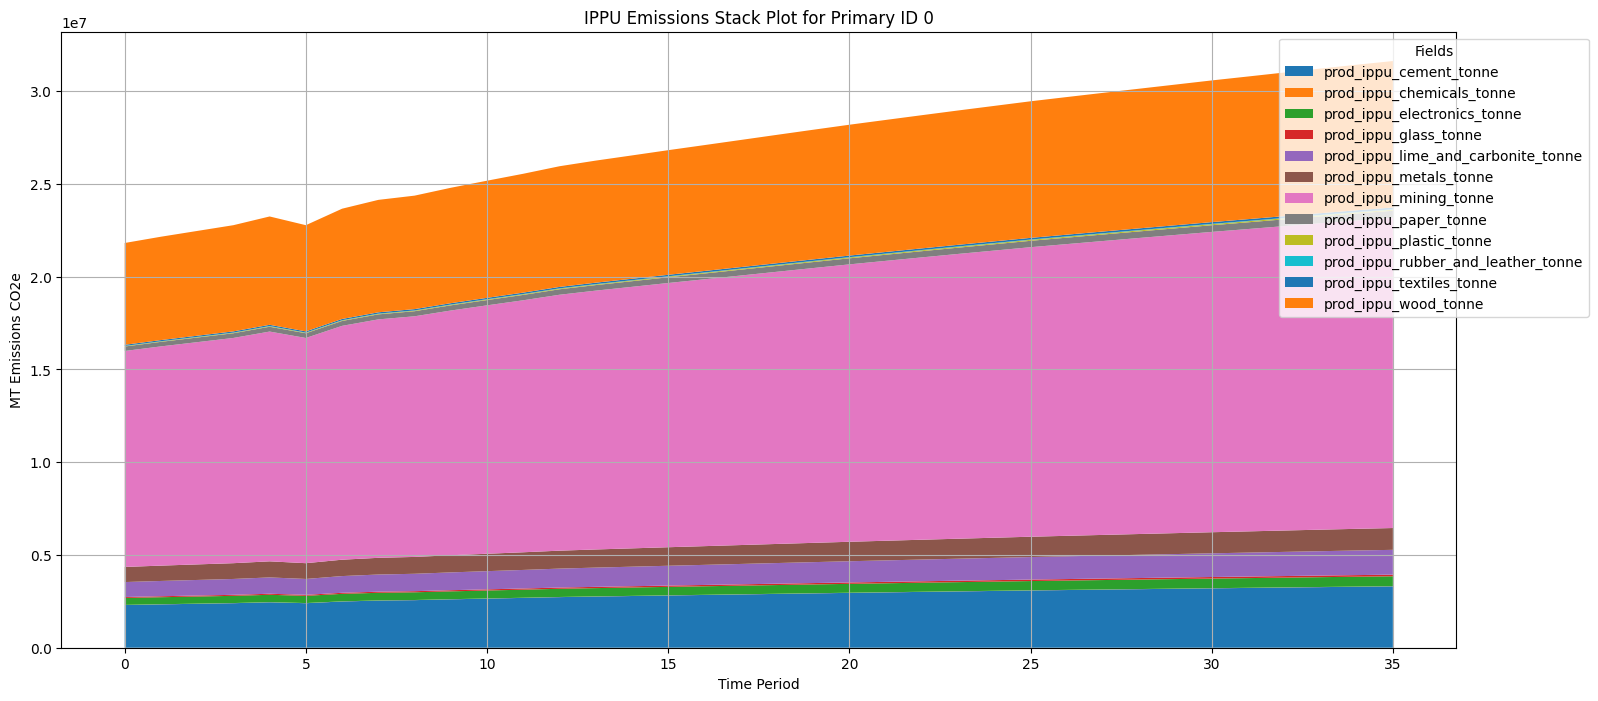

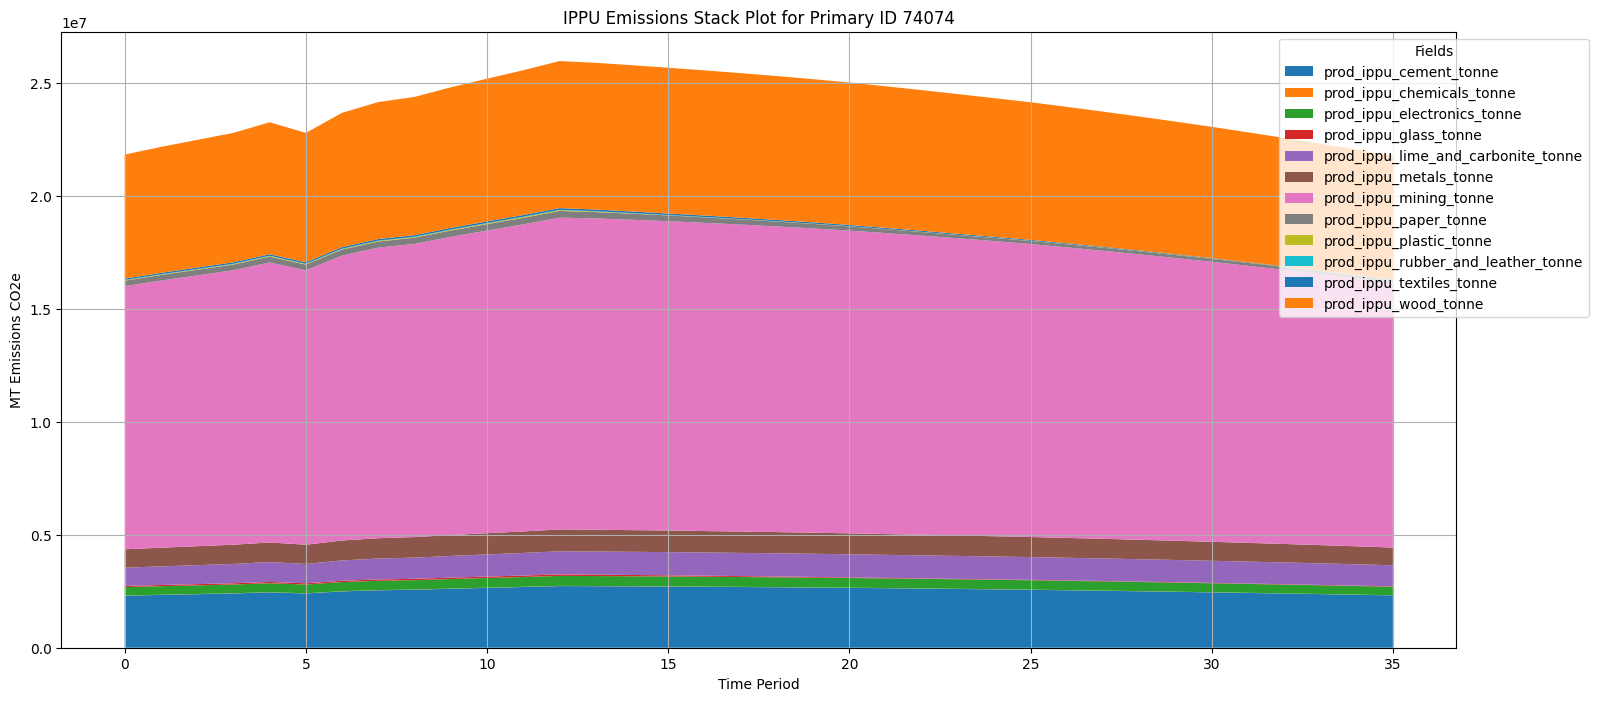

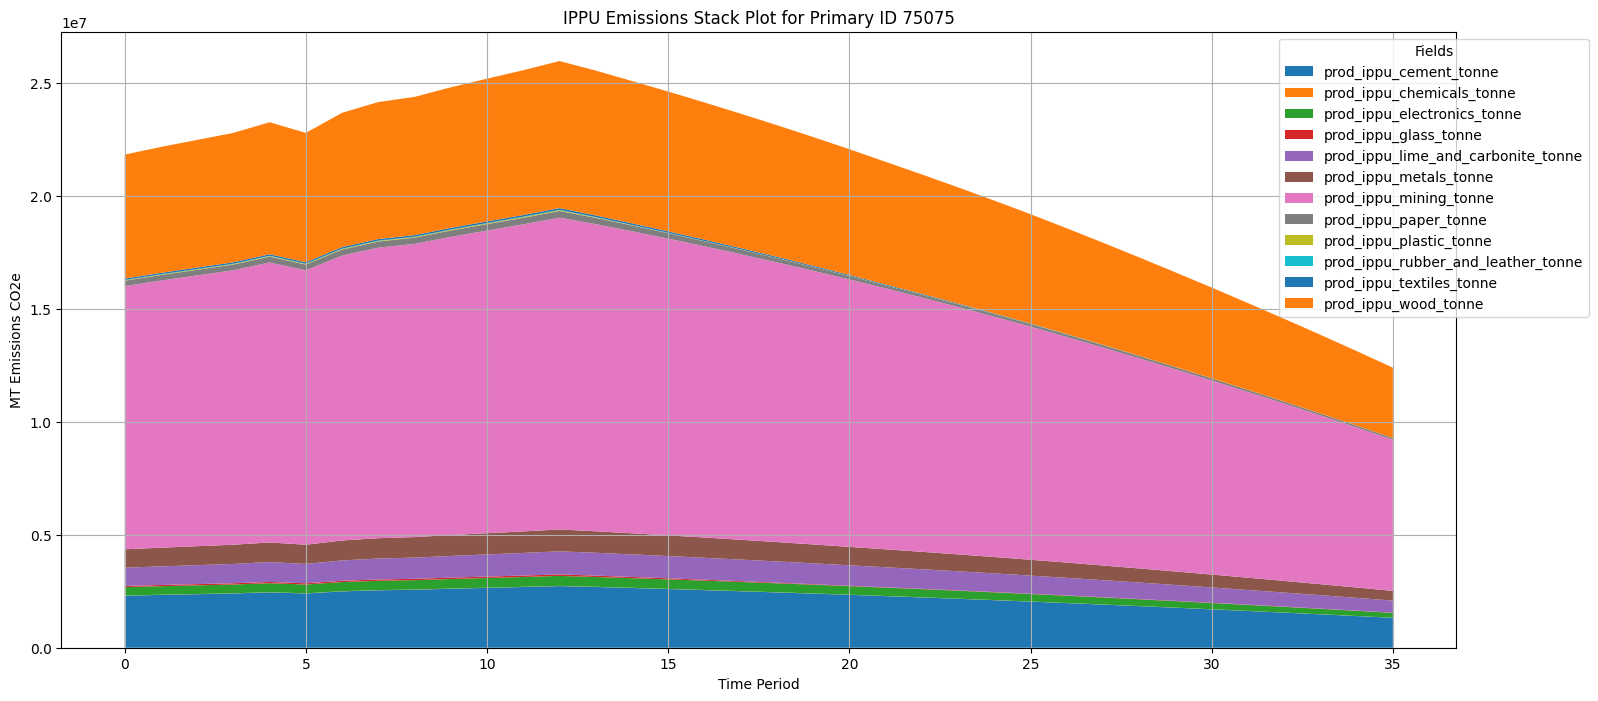

prod_ippu_mining_tonne                1.285360e+07
prod_ippu_wood_tonne                  6.060552e+06
prod_ippu_cement_tonne                2.542267e+06
prod_ippu_lime_and_carbonite_tonne    9.255717e+05
prod_ippu_metals_tonne                9.004595e+05
prod_ippu_electronics_tonne           4.119195e+05
prod_ippu_paper_tonne                 2.708149e+05
prod_ippu_textiles_tonne              7.012332e+04
prod_ippu_glass_tonne                 5.929920e+04
prod_ippu_plastic_tonne               2.970221e+04
prod_ippu_rubber_and_leather_tonne    1.117813e+04
prod_ippu_chemicals_tonne             6.730456e+03
Name: 7, dtype: float64


In [163]:
ippu_production_fields = matt.get_variable("Industrial Production").fields

for primary_id in primary_ids_to_plot:

    plot_field_stack(
        df_out,
        ippu_production_fields,
        dict_format,
        primary_id=primary_id,
        title=f"IPPU Emissions Stack Plot for Primary ID {primary_id}"
    )

print(df_out[df_out.primary_id == 0][ippu_production_fields].loc[7].sort_values(ascending=False))

In [164]:
# ippu_fields = ['emission_co2e_subsector_total_ippu']

# for primary_id in primary_ids_to_plot:

#     plot_field_stack(
#         df_out,
#         ippu_fields,
#         dict_format,
#         primary_id=primary_id,
#         title=f"IPPU Emissions Stack Plot for Primary ID {primary_id}"
#     )

In [165]:
# waste_fields = [
#     'emission_co2e_subsector_total_waso',
#     'emission_co2e_subsector_total_trww',
# ]

# for primary_id in primary_ids_to_plot:

#     plot_field_stack(
#         df_out,
#         waste_fields,
#         dict_format,
#         primary_id=primary_id,
#         title=f"Waste Emissions Stack Plot for Primary ID {primary_id}"
#     )


In [166]:
# subsector_emission_fields

In [167]:
# df_out['emission_co2e_subsector_total_fgtv']

In [168]:
# fgtv_fields = ['emission_co2e_subsector_total_fgtv']

# for primary_id in primary_ids_to_plot:

#     plot_field_stack(
#         df_out,
#         fgtv_fields,
#         dict_format,
#         primary_id=primary_id,
#         title=f"FGTV Emissions Stack Plot for Primary ID {primary_id}"
#     )

In [169]:
# fgtv_fields = ['emission_co2e_subsector_total_trns']

# for primary_id in primary_ids_to_plot:

#     plot_field_stack(
#         df_out,
#         fgtv_fields,
#         dict_format,
#         primary_id=primary_id,
#         title=f"Transport Emissions Stack Plot for Primary ID {primary_id}"
#     )

In [170]:
# # Plot non energy emissions stack
# non_energy_fields = [
# 'emission_co2e_subsector_total_agrc',
#  'emission_co2e_subsector_total_frst',
#  'emission_co2e_subsector_total_lndu',
#  'emission_co2e_subsector_total_lsmm',
#  'emission_co2e_subsector_total_lvst',
#  'emission_co2e_subsector_total_soil',
#  'emission_co2e_subsector_total_waso',
#  'emission_co2e_subsector_total_trww',
#  'emission_co2e_subsector_total_ippu'
# ]

# for primary_id in primary_ids_to_plot:

#     plot_field_stack(
#         df_out,
#         non_energy_fields,
#         dict_format,
#         primary_id=primary_id,
#         title=f"Emissions Stack Plot for Primary ID {primary_id}"
#     )

## Check Crop Demand and Yield


In [171]:
# crop_demand_fields = [col for col in df_out.columns if 'demand_agrc_' in col]
# crop_yield_fields = [col for col in df_out.columns if 'yield_agrc_' in col]

In [172]:
# for primary_id in primary_ids_to_plot:

#     plot_field_stack(
#         df_out,
#         crop_demand_fields,
#         dict_format,
#         primary_id=primary_id,
#         title=f"Crop Demand Over Time for Primary ID {primary_id}",
#         ylabel="Crop Demand (Tonnes)"
#     )
#     print(df_out[df_out[ssp.key_primary]==primary_id][crop_demand_fields].iloc[7])

In [173]:
# for primary_id in primary_ids_to_plot:

#     plot_field_stack(
#         df_out,
#         crop_yield_fields,
#         dict_format,
#         primary_id=primary_id,
#         title=f"Crop Yield Over Time for Primary ID {primary_id}",
#         ylabel="Crop Yield (Tonnes/Ha)"
#     )

#     print(df_out[df_out[ssp.key_primary]==primary_id][crop_yield_fields].iloc[7].sort_values(ascending=False))

In [174]:
# yield_factor_fields = matt.get_variable("Crop Yield Factor").fields

# for primary_id in primary_ids_to_plot:
#     plot_field_stack(
#         df_in,
#         yield_factor_fields,
#         dict_format,
#         primary_id=primary_id,
#         title=f"Crop Yield Factor Over Time for Primary ID {primary_id}",
#         ylabel="Crop Yield Factor"
#     )
#     print(df_in[df_in[ssp.key_primary]==primary_id][yield_factor_fields].iloc[7].sort_values(ascending=False))

### Livestock Check

In [175]:
# lvst_pop_fields = matt.get_variable("Livestock Head Count").fields

# for primary_id in primary_ids_to_plot:
#     plot_field_stack(
#         df_out,
#         lvst_pop_fields,
#         dict_format,
#         primary_id=primary_id,
#         title=f"Livestock Head Count Over Time for Primary ID {primary_id}"
# )

In [176]:
# crop_residues_fields = ["emission_co2e_n2o_agrc_crop_residues"]

# for primary_id in primary_ids_to_plot:

#     plot_field_stack(
#         df_out,
#         crop_residues_fields,
#         dict_format,
#         primary_id=primary_id,
#         title=f"Crop Residues Emissions Over Time for Primary ID {primary_id}",
#         ylabel="MT Emissions CO2e from Crop Residues"
#     )

In [177]:
# co2_agrc_fields = [
#     "emission_co2e_co2_agrc_biomass_bevs_and_spices",
#     "emission_co2e_co2_agrc_biomass_fruits",
#     "emission_co2e_co2_agrc_biomass_nuts",
#     "emission_co2e_co2_agrc_biomass_other_woody_perennial",
# ]
# for primary_id in primary_ids_to_plot:

#     plot_field_stack(
#         df_out,
#         co2_agrc_fields,
#         dict_format,
#         primary_id=primary_id,
#         title=f"CO2 Agriculture Emissions Over Time for Primary ID {primary_id}",
#         ylabel="MT CO2 Emissions"
#     )

#     print(df_out[df_out[ssp.key_primary]==primary_id][co2_agrc_fields].iloc[-1].sort_values(ascending=False))

In [178]:
# ch4_agrc_fields = ["emission_co2e_ch4_agrc_anaerobicdom_rice", "emission_co2e_ch4_agrc_biomass_burning"]
# for primary_id in primary_ids_to_plot:

#     plot_field_stack(
#         df_out,
#         ch4_agrc_fields,
#         dict_format,
#         primary_id=primary_id,
#         title=f"CH4 Agriculture Emissions Over Time for Primary ID {primary_id}",
#         ylabel="MT CH4 Emissions"
#     )

#     print(df_out[df_out[ssp.key_primary]==primary_id][ch4_agrc_fields].iloc[-1].sort_values(ascending=False))

In [179]:
# n20_agrc_fields = ["emission_co2e_n2o_agrc_biomass_burning", "emission_co2e_n2o_agrc_crop_residues"]
# for primary_id in primary_ids_to_plot:

#     plot_field_stack(
#         df_out,
#         n20_agrc_fields,
#         dict_format,
#         primary_id=primary_id,
#         title=f"N2O Agriculture Emissions Over Time for Primary ID {primary_id}",
#         ylabel="MT N2O Emissions"
#     )

#     print(df_out[df_out[ssp.key_primary]==primary_id][n20_agrc_fields].iloc[-1].sort_values(ascending=False))

## Fix FGTV when having super large spikes (Only use when there are spikes)

In [145]:
primary_id_to_fix = 0
df_out[df_out.primary_id==primary_id_to_fix][[col for col in df_out.columns if 'fgtv' in col]].plot(figsize=(10,5))

TypeError: no numeric data to plot

In [146]:
def hampel_clean(
    s: pd.Series,
    window: int = 7,
    n_sigmas: float = 5.0,
    strategy: str = "prev",  # "prev" | "median" | "linear" | "nan"
):
    """
    Detects spikes using a rolling median + MAD (Hampel) and replaces them.

    Returns
    -------
    cleaned : pd.Series
    mask : pd.Series[bool]  # True where a spike was found
    """
    s = s.astype(float).copy()

    # Rolling median
    med = s.rolling(window, center=True, min_periods=max(3, window//2)).median()

    # Rolling MAD (median absolute deviation)
    def _mad(x):
        m = np.median(x)
        return np.median(np.abs(x - m))
    mad = s.rolling(window, center=True, min_periods=max(3, window//2)).apply(_mad, raw=False)

    # Robust z-score using MAD (~= std when multiplied by 1.4826)
    sigma = 1.4826 * mad
    # Fallbacks at edges
    med = med.fillna(s.median())
    sigma = sigma.replace(0, np.nan).fillna(sigma[sigma>0].median() or 1.0)

    z = (s - med).abs() / sigma
    mask = z > n_sigmas  # spike locations (True = spike)

    # Impute
    cleaned = s.copy()
    if strategy == "prev":
        # copy previous *valid* value
        # (for first element or consecutive spikes, fall back to local median)
        for idx in np.where(mask)[0]:
            if idx > 0 and not np.isnan(cleaned.iloc[idx-1]):
                cleaned.iloc[idx] = cleaned.iloc[idx-1]
            else:
                cleaned.iloc[idx] = med.iloc[idx]
    elif strategy == "median":
        cleaned[mask] = med[mask]
    elif strategy == "linear":
        tmp = cleaned.copy()
        tmp[mask] = np.nan
        cleaned = tmp.interpolate(method="linear", limit_direction="both")
    elif strategy == "nan":
        cleaned[mask] = np.nan
    else:
        raise ValueError("Unknown strategy")

    return cleaned, mask

# --- Example on your Series s ---
# s_clean, spike_mask = hampel_clean(s, window=7, n_sigmas=5.0, strategy="prev")


In [147]:
# select the subset
subset = df_out[df_out.primary_id == primary_id_to_fix].copy()

# get only the relevant columns
cols = [c for c in df_out.columns if 'fgtv' in c]

# make a copy to store cleaned results
cleaned_subset = subset.copy()
spike_masks = {}

# apply Hampel cleaning to each relevant column
for c in cols:
    cleaned_subset[c], spike_masks[c] = hampel_clean(
        subset[c],
        window=7,
        n_sigmas=5.0,
        strategy="prev"  # or "median"/"linear"
    )

# if you want to merge back into df_out:
df_out.loc[df_out.primary_id == primary_id_to_fix, cols] = cleaned_subset[cols]

In [148]:
df_out[df_out.primary_id==primary_id_to_fix][[col for col in df_out.columns if 'fgtv' in col]].plot(figsize=(10,10))

TypeError: no numeric data to plot

<Axes: >

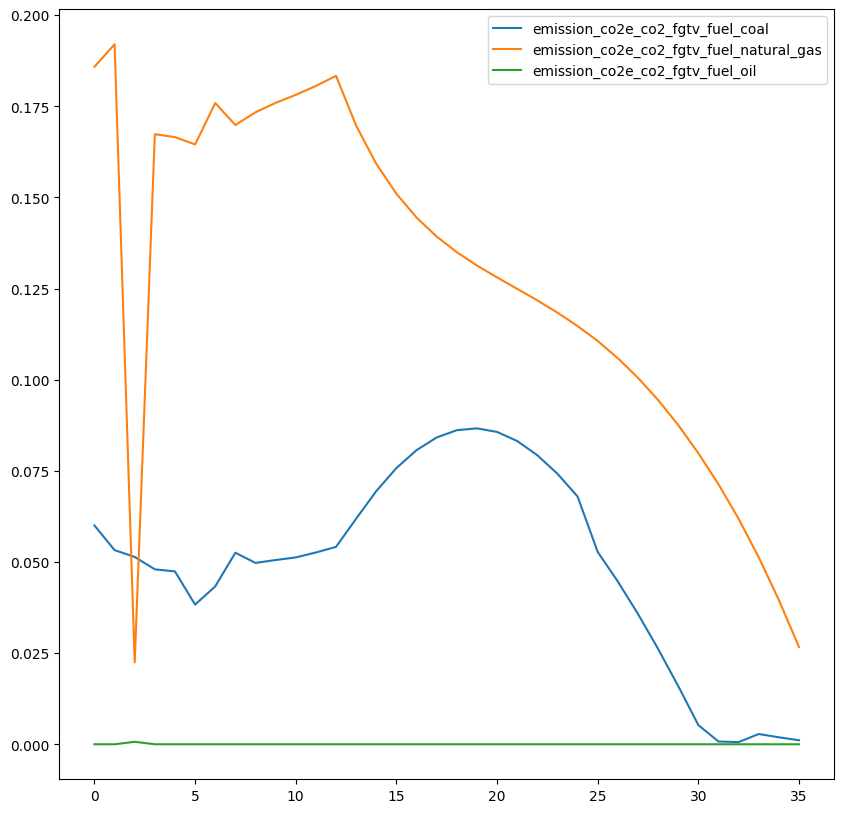

In [159]:
df_out[df_out.primary_id==75075][[col for col in df_out.columns if 'fgtv' in col and 'co2_' in col]].reset_index(drop=True).plot(figsize=(10,10))

# Export Wide File (Last Mandatory Step)

In [180]:
all_primaries = sorted(list(df_out[ssp.key_primary].unique()))

# build if unable to simply read the data frame
if df_in is None:
    df_in = []
     
    for region in ssp.regions:
        for primary in all_primaries: 
            df_in_filt = ssp.generate_scenario_database_from_primary_key(primary)
            df_in.append(df_in_filt.get(region))
    
    df_in = pd.concat(df_in, axis = 0).reset_index(drop = True)




df_export = pd.merge(
    df_out,
    df_in,
    how = "left",
)



# check output directory 
dir_pkg = os.path.join(
    ssp.file_struct.dir_out, 
    f"sisepuede_summary_results_run_{ssp.id_fs_safe}"
)
os.makedirs(dir_pkg) if not os.path.exists(dir_pkg) else None


for tab in ["ATTRIBUTE_STRATEGY"]:
    table_df = ssp.database.db.read_table(tab)
    if table_df is not None:
        table_df.to_csv(
            os.path.join(dir_pkg, f"{tab}.csv"),
            index=None,
            encoding="UTF-8"
        )
    else:
        print(f"Warning: Table {tab} returned None.")


df_primary = (
    ssp
    .odpt_primary
    .get_indexing_dataframe(
        sorted(list(df_out[ssp.key_primary].unique()))
    )
)
    
df_primary.to_csv(
    os.path.join(dir_pkg, f"ATTRIBUTE_PRIMARY.csv"),
    index = None,
    encoding = "UTF-8"
)

df_export.to_csv(
    os.path.join(dir_pkg, f"sisepuede_results_{ssp.id_fs_safe}_WIDE_INPUTS_OUTPUTS.csv"),
    index = None,
    encoding = "UTF-8"
)

In [181]:
# Getting the directory where the outputs are stored
ssp.file_struct.dir_out

'/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/sisepuede/out'

In [182]:
RUN_ID_OUTPUT_DIR_PATH = os.path.join(
    RUN_OUTPUT_DIR_PATH, 
    f"sisepuede_results_{ssp.id_fs_safe}"
)

os.makedirs(RUN_ID_OUTPUT_DIR_PATH, exist_ok=True)

df_primary.to_csv(
    os.path.join(RUN_ID_OUTPUT_DIR_PATH, "ATTRIBUTE_PRIMARY.csv"),
    index = None,
    encoding = "UTF-8"
)

df_export.to_csv(
    os.path.join(RUN_ID_OUTPUT_DIR_PATH, f"sisepuede_results_{ssp.id_fs_safe}_WIDE_INPUTS_OUTPUTS.csv"),
    index = None,
    encoding = "UTF-8"
)

for tab in ["ATTRIBUTE_STRATEGY"]:
    table_df = ssp.database.db.read_table(tab)
    if table_df is not None:
        table_df.to_csv(
            os.path.join(RUN_ID_OUTPUT_DIR_PATH, f"{tab}.csv"),
            index=None,
            encoding="UTF-8"
        )
    else:
        logger.warning(f"Warning: Table {tab} returned None.")

In [183]:
tableau_levers_table_csv.to_csv(
            os.path.join(RUN_ID_OUTPUT_DIR_PATH, "tableau_levers_table.csv"),
            index=None,
            encoding="UTF-8"
        )

In [184]:
RUN_ID_OUTPUT_DIR_PATH

'/Users/tony/Documents/sisepuede_modeling/ssp_bulgaria/ssp_modeling/ssp_run_output/sisepuede_results_sisepuede_run_2025-12-04T17;43;07.880827'

In [185]:
# gdp_df = df_in[["time_period", "gdp_mmm_usd"]].copy()
# gdp_df["year"] = gdp_df["time_period"] + 2015
# gdp_df = gdp_df.drop(columns=["time_period"])
# gdp_df.head()

### Code to create drivers prep table if necessary

In [186]:
# import sisepuede.core.information_table_properties as scip
# new_drivers_df = scip.build_variable_information_table(model_attributes=matt, modvars=None)

In [187]:
# new_drivers_df.to_csv("drivers.csv", index=False)